# Introducción a *Machine Learning*
## Aprendizaje supervisado, StatsModels, Scikit-Learn, Perceptrón y Adaline

**Curso:** Analítica de Datos  
**Docente:** Carlos Alberto Ramos Ortiz  

> **Idea central:** un modelo no es el final del análisis. Es una herramienta para convertir datos en evidencia, cuantificar incertidumbre y apoyar decisiones.

> ### Aviso ético del caso de estudio
> Usaremos el conjunto **Breast Cancer Wisconsin (Diagnostic)** para aprender un flujo de clasificación. Los resultados son exclusivamente educativos: no constituyen diagnóstico médico ni sustituyen el criterio clínico. En una aplicación real se requieren validación externa, evaluación de sesgos, supervisión profesional y protocolos de seguridad.

## Objetivos de aprendizaje

Al terminar la clase, el estudiante podrá:

1. Explicar qué es *machine learning* y diferenciar clasificación de regresión.
2. Identificar $X$, $y$, observaciones, variables y predicción en un problema supervisado.
3. Separar entrenamiento y prueba sin producir **fuga de información**.
4. Distinguir el enfoque inferencial de **StatsModels** del flujo predictivo de **Scikit-Learn**.
5. Construir y evaluar una regresión logística con ambas bibliotecas.
6. Explicar y programar desde cero el **Perceptrón** y **Adaline**.
7. Interpretar matriz de confusión, precisión, sensibilidad, $F_1$, ROC-AUC y validación cruzada.
8. Comunicar una recomendación basada en evidencia, reconociendo las limitaciones del modelo.

## Ruta de la clase

1. Del análisis de datos al aprendizaje automático.
2. Aprendizaje supervisado y generalización.
3. Caso real: clasificación de tumores.
4. StatsModels: inferencia mediante regresión logística.
5. Scikit-Learn: predicción, *pipelines* y evaluación.
6. Perceptrón: aprendizaje basado en errores de clasificación.
7. Adaline: aprendizaje mediante una función de costo diferenciable.
8. Comparación, buenas prácticas, ejercicios y reto integrador.

In [1]:
%mamba install numpy pandas matplotlib seaborn scikit-learn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 5.108 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.7.22  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.5.1      pyhd8ed1ab_0         conda-forge
+ idna                3.19       pyhcf101f3_0         conda-forge
+ joblib              1.5.3      py313h1804a44_3      emscripten-forge-4x
+ narwhals            2.25.0     pyhcf101f3_0         conda-forge
+ pandas              3.0.5      np23py313h1e705a5_0  emscripten-forge-4x
+ patsy               1.0.2      py313h1804a44_3      emscripten-forge-4x
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ p

# 1. ¿Qué es *machine learning*?

El **aprendizaje automático** estudia métodos que encuentran patrones en datos para realizar predicciones o tomar decisiones sobre observaciones nuevas.

**“El aprendizaje automático es un subdominio de la IA que proporciona a los sistemas la capacidad de aprender y mejorar automáticamente a partir de la experiencia sin ser programados explícitamente. Se basa en la hipótesis subyacente de crear el modelo y tratar de mejorarlo ajustando más datos en el modelo a lo largo del tiempo.”**

Una forma útil de verlo es:

$$\text{Experiencia(datos históricos)} + \text{algoritmo} \longrightarrow \text{modelo aprendido}$$

El algoritmo es el procedimiento de aprendizaje; el modelo es el resultado ajustado. Por ejemplo, `LogisticRegression` es un algoritmo/estimador y sus coeficientes ajustados constituyen el modelo aprendido.

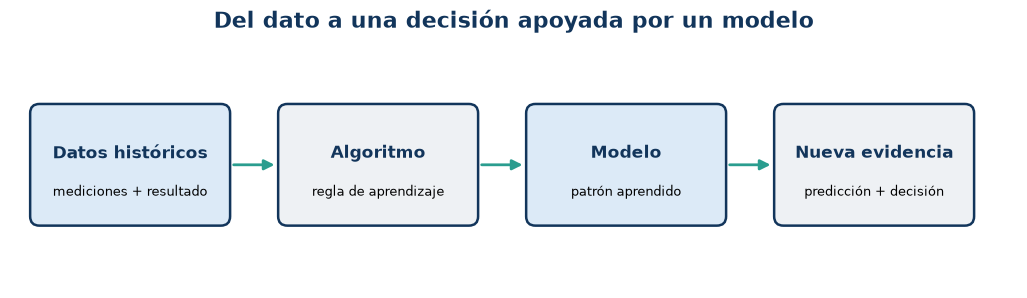

In [3]:
from matplotlib import pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

AZUL = "#12355B"
AZUL_CLARO = "#DCEAF7"
GRIS = "#EEF1F4"
VERDE = "#2A9D8F"
NARANJA = "#F4A261"
ROJO = "#D1495B"

fig, ax = plt.subplots(figsize=(13, 3.2))
ax.set_xlim(0, 13)
ax.set_ylim(0, 3.2)
ax.axis("off")

etapas = [
    (0.3, "Datos históricos", "mediciones + resultado"),
    (3.5, "Algoritmo", "regla de aprendizaje"),
    (6.7, "Modelo", "patrón aprendido"),
    (9.9, "Nueva evidencia", "predicción + decisión"),
]
for i, (x, titulo, subtitulo) in enumerate(etapas):
    caja = FancyBboxPatch((x, 0.85), 2.5, 1.5,
                          boxstyle="round,pad=0.04,rounding_size=0.12",
                          facecolor=AZUL_CLARO if i % 2 == 0 else GRIS,
                          edgecolor=AZUL, linewidth=1.8)
    ax.add_patch(caja)
    ax.text(x + 1.25, 1.75, titulo, ha="center", va="center",
            fontsize=12, fontweight="bold", color=AZUL)
    ax.text(x + 1.25, 1.25, subtitulo, ha="center", va="center", fontsize=9)
    if i < len(etapas) - 1:
        ax.add_patch(FancyArrowPatch((x + 2.55, 1.6), (x + 3.15, 1.6),
                                     arrowstyle="-|>", mutation_scale=15,
                                     color=VERDE, linewidth=2))

ax.set_title("Del dato a una decisión apoyada por un modelo", fontsize=16,
             fontweight="bold", color=AZUL, pad=10)
plt.show()

## Ejemplo:

**Se plantea la construcción de un filtro capaz de identificar y bloquear correos de SPAM**:

- Desde el enfoque Clásico (depende 100% del analísta):

  Humano → crea las reglas → Computador aplica las reglas
  <center>
  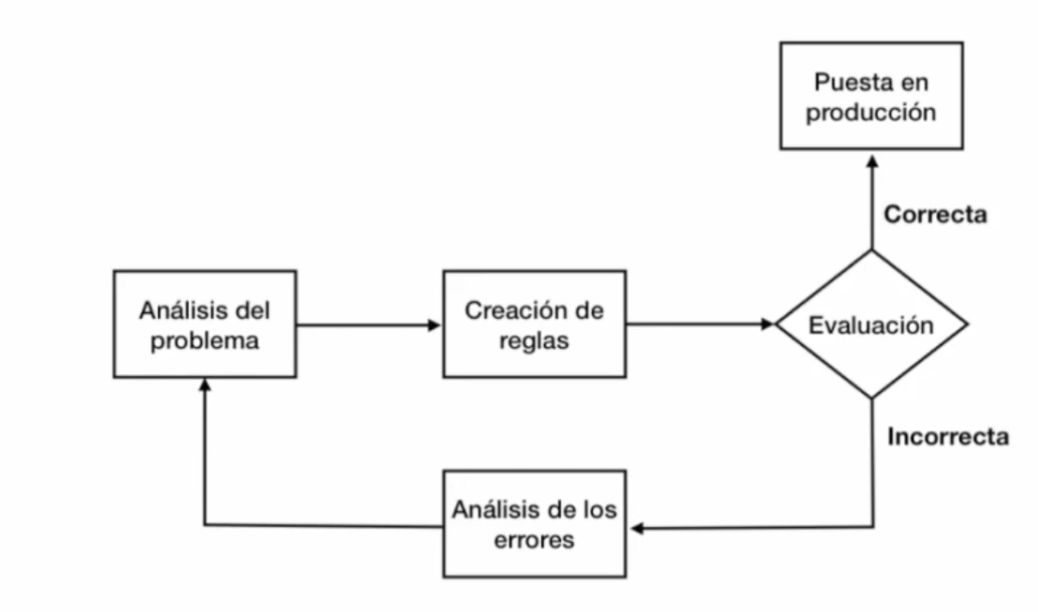
  </center>

- Desde el enfoque del Machine-Learning (depende del modelo y no necesariamente de las reglas internas):

  Humano → proporciona datos → Algoritmo aprende → Modelo clasifica nuevos datos
  <center>
  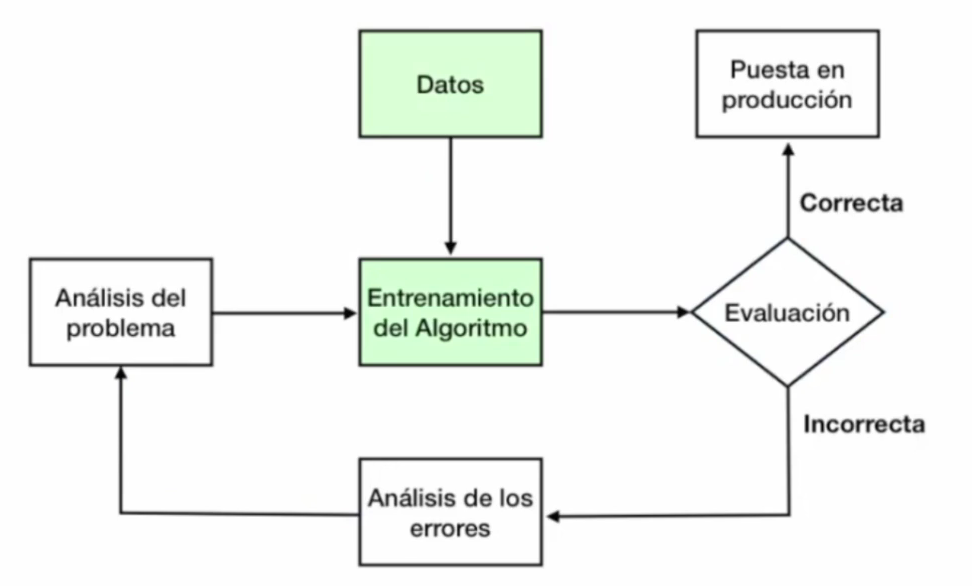
  </center>

### ¿Cuándo utilizar Machine Learning?

El uso de **Machine Learning** resulta especialmente apropiado en los siguientes casos:

- Cuando una solución requiere la aplicación de un conjunto muy extenso de **reglas o heurísticas**, cuya programación y mantenimiento manual serían difíciles.

- Cuando se abordan **problemas complejos** en los que un analista no puede determinar fácilmente una solución a partir de la información disponible.

- Cuando se trabaja en **entornos dinámicos** que fluctúan o cambian con frecuencia, por lo que las reglas establecidas pueden quedar rápidamente desactualizadas.

- Como apoyo en la fase de análisis de enfoques tradicionales, especialmente cuando se dispone de **grandes volúmenes de datos** que son difíciles de interpretar mediante métodos convencionales.

> **Idea:** Machine Learning es especialmente útil cuando existen datos suficientes para identificar patrones, pero resulta difícil construir manualmente todas las reglas necesarias para resolver el problema.

## Clasificación de los sistemas de Machine Learning

Los sistemas de **Machine Learning** pueden clasificarse utilizando diferentes criterios. Estas clasificaciones no son excluyentes: un mismo sistema puede pertenecer simultáneamente a varias categorías.

### 1. Según la forma en que se entrenan

- **Aprendizaje supervisado:** el modelo se entrena con datos que incluyen las respuestas correctas o etiquetas.
- **Aprendizaje no supervisado:** el modelo trabaja con datos sin etiquetar e intenta descubrir patrones o estructuras.
- **Aprendizaje semisupervisado:** combina una pequeña cantidad de datos etiquetados con una gran cantidad de datos sin etiquetar.
- **Aprendizaje por refuerzo:** un agente aprende mediante la interacción con un entorno, recibiendo recompensas o penalizaciones.

### 2. Según la manera en que aprenden a lo largo del tiempo

- **Aprendizaje en línea (*online learning*):** el modelo se actualiza de manera continua o progresiva a medida que recibe nuevas observaciones.
- **Aprendizaje por lotes (*batch learning*):** el modelo se entrena utilizando todo el conjunto de datos disponible y debe volver a entrenarse para incorporar nueva información.

### 3. Según la forma en que realizan las predicciones

- **Aprendizaje basado en instancias:** compara las nuevas observaciones con ejemplos conocidos del conjunto de entrenamiento.
- **Aprendizaje basado en modelos:** construye un modelo general a partir de los datos y utiliza ese modelo para realizar predicciones.

> **Importante:** estas clasificaciones responden a preguntas diferentes:  
> ¿qué información se utiliza para aprender?, ¿cómo se actualiza el aprendizaje? y ¿cómo se generan las predicciones?

## Principales paradigmas de Machine Learning

Los paradigmas de Machine Learning se diferencian principalmente por el tipo de información disponible durante el entrenamiento y por el objetivo que se desea alcanzar.

| Paradigma | ¿Hay variable objetivo $y$? | Pregunta típica | Ejemplo |
|:---|:---:|:---|:---|
| **Supervisado** | Sí | ¿Qué resultado tendrá una nueva observación? | Predecir el abandono de clientes, el precio de una vivienda o un diagnóstico |
| **No supervisado** | No | ¿Qué patrones o estructuras existen en los datos? | Segmentar clientes o identificar grupos de observaciones similares |
| **Semisupervisado** | Parcialmente | ¿Cómo aprovechar muchos datos sin etiquetar y pocos datos etiquetados? | Clasificar imágenes cuando solo una pequeña parte tiene etiquetas |
| **Por refuerzo** | No de forma convencional; existe una recompensa | ¿Qué acción maximiza la recompensa acumulada? | Controlar un robot, diseñar la estrategia de un agente o jugar un videojuego |

### Interpretación

- En el **aprendizaje supervisado**, el algoritmo conoce las respuestas correctas durante el entrenamiento.
- En el **aprendizaje no supervisado**, no existen respuestas conocidas y se buscan patrones en los datos.
- En el **aprendizaje semisupervisado**, solamente una parte de las observaciones posee una respuesta o etiqueta.
- En el **aprendizaje por refuerzo**, un agente aprende cuáles acciones debe realizar mediante recompensas y penalizaciones.


 <center>
  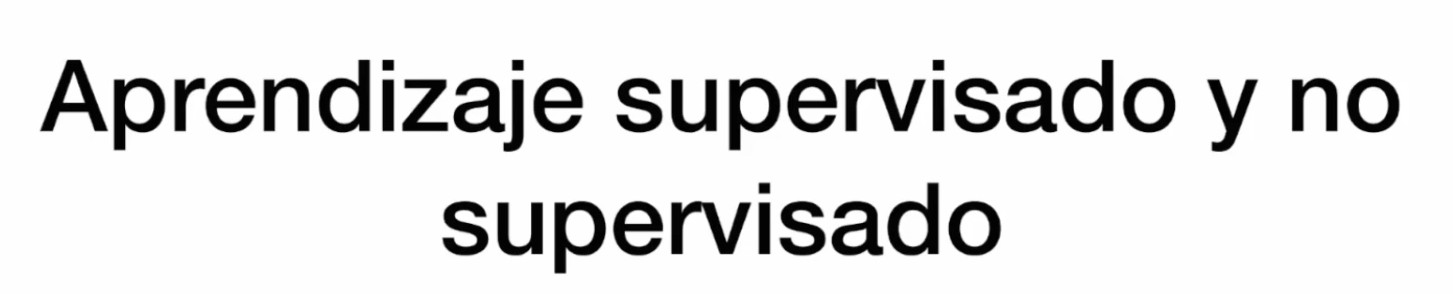
  </center>

<center>
  <img src="attachment:a0d14346-3961-4564-834e-8c6d29c63564.png" width="500">
  </center>

## Aprendizaje supervisado

El **aprendizaje supervisado** es una rama del Machine Learning cuyo objetivo es aprender una función que relacione unas variables de entrada con una variable de salida, utilizando ejemplos en los que se conoce la respuesta correcta.

Durante el entrenamiento, el algoritmo recibe pares de entrada–salida:

$$
(\mathbf{x}_i,y_i),
$$

donde $\mathbf{x}_i$ contiene las características de la observación $i$ y $y_i$ representa su respuesta o etiqueta conocida.

A partir de estos ejemplos, el algoritmo construye una función o modelo:

$$
h:\mathcal{X}\longrightarrow\mathcal{Y},
$$

de manera que:

$$
\widehat{y}=h(\mathbf{x}).
$$

Aquí, $\widehat{y}$ representa la predicción generada por el modelo para una nueva observación $\mathbf{x}$.

### Esquema general

 <center>
  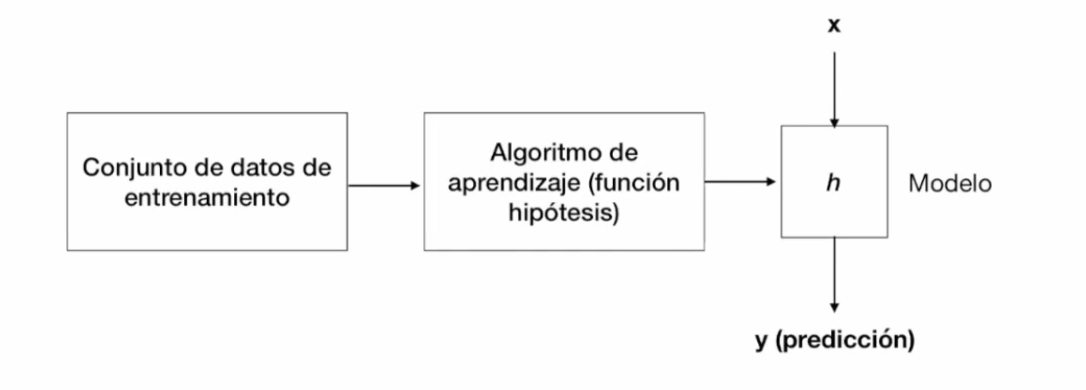
  </center>

1. Se dispone de un **conjunto de datos de entrenamiento etiquetado**.
2. El algoritmo analiza la relación entre las características y la variable objetivo.
3. Como resultado del entrenamiento, se obtiene un modelo o función hipótesis $h$.
4. El modelo recibe las características de una nueva observación.
5. Finalmente, produce una predicción $\widehat{y}$.

| Etapa | Entrada | Proceso o resultado |
|:---|:---|:---|
| **Entrenamiento** | Pares conocidos $(\mathbf{x}_i,y_i)$ | El algoritmo aprende el modelo $h$ |
| **Predicción** | Nueva observación $\mathbf{x}_{\text{nueva}}$ | El modelo calcula $\widehat{y}=h(\mathbf{x}_{\text{nueva}})$ |

> **Idea:** durante el entrenamiento conocemos tanto las características como las respuestas. Posteriormente, utilizamos el modelo aprendido para predecir las respuestas de observaciones nuevas.

## Formulación matemática del aprendizaje supervisado

En el aprendizaje supervisado se dispone de un conjunto de $n$ observaciones etiquetadas:

$$
\mathcal{D}
=
\left\{
(\mathbf{x}_i,y_i)
\right\}_{i=1}^{n}.
$$

Cada observación está formada por un vector de características y una respuesta conocida:

$$
\mathbf{x}_i
=
\left(
x_{i1},x_{i2},\ldots,x_{ip}
\right)^{\mathsf{T}},
$$

donde:

- $n$ es el número total de observaciones.
- $p$ es el número de variables predictoras o características.
- $\mathbf{x}_i$ es el vector de características correspondiente a la observación $i$.
- $x_{ij}$ es el valor de la característica $j$ en la observación $i$.
- $y_i$ es la respuesta, etiqueta o variable objetivo de la observación $i$.

Al organizar todas las observaciones, se obtiene la matriz de características:

$$
\mathbf{X}
=
\begin{pmatrix}
x_{11} & x_{12} & \cdots & x_{1p}\\
x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \ddots & \vdots\\
x_{n1} & x_{n2} & \cdots & x_{np}
\end{pmatrix}
\in\mathbb{R}^{n\times p},
$$

y el vector de respuestas:

$$
\mathbf{y}
=
\begin{pmatrix}
y_1\\
y_2\\
\vdots\\
y_n
\end{pmatrix}.
$$

El algoritmo utiliza los datos de entrenamiento para aprender una función parametrizada:

$$
f_{\widehat{\boldsymbol{\theta}}}:\mathcal{X}\longrightarrow\mathcal{Y},
$$

donde $\widehat{\boldsymbol{\theta}}$ representa los parámetros estimados durante el entrenamiento.

Para una nueva observación $\mathbf{x}_{\mathrm{nueva}}$, la predicción se calcula mediante:

$$
\widehat{y}_{\mathrm{nueva}}
=
f_{\widehat{\boldsymbol{\theta}}}
\left(
\mathbf{x}_{\mathrm{nueva}}
\right).
$$

## El objetivo: generalizar

El propósito del aprendizaje supervisado no es memorizar los datos utilizados durante el entrenamiento, sino aprender patrones que permitan realizar buenas predicciones sobre observaciones nuevas provenientes de la misma población o proceso.

> **Generalización:** capacidad de un modelo para mantener un buen desempeño cuando recibe datos que no fueron utilizados durante su entrenamiento.

## Clasificación y regresión

| Aspecto | Clasificación | Regresión |
|---|---|---|
| Tipo de $y$ | Categórica | Numérica continua |
| Ejemplo | maligno/benigno | precio de una vivienda |
| Salida | clase o probabilidad | valor numérico |
| Métricas comunes | *recall*, precisión, $F_1$, ROC-AUC | MAE, RMSE, (R^2) |

**Advertencia:** la *regresión logística*, pese a su nombre, es un método de **clasificación**, pues modela una probabilidad y aplica un umbral para decidir la clase.

## Regresión

La **regresión** es una tarea de aprendizaje supervisado cuyo objetivo es predecir una variable cuantitativa que puede tomar valores dentro de un intervalo continuo.

En este caso, la variable objetivo cumple:

$$
y\in\mathbb{R}.
$$

El modelo aprende una función que relaciona las características de entrada $\mathbf{x}$ con una respuesta numérica:

$$
\widehat{y}=f(\mathbf{x}),
$$

donde $\widehat{y}$ es el valor predicho para una nueva observación.

### Ejemplos de problemas de regresión

- Predecir el precio de una vivienda.
- Estimar las ventas mensuales de una empresa.
- Pronosticar la temperatura del día siguiente.
- Estimar el costo de mantenimiento de un vehículo.
- Predecir el tiempo de recuperación de un paciente.

### Ejemplo: costo de mantenimiento de un vehículo

Supongamos que queremos estimar el costo anual de mantenimiento de un vehículo utilizando su antigüedad:

- Variable predictora: antigüedad del vehículo en años.
- Variable objetivo: costo anual de mantenimiento.
- Tipo de problema: regresión, porque el costo es una cantidad numérica continua.

En una regresión lineal simple, el modelo tiene la forma:

$$
\widehat{y}=\widehat{\beta}_0+\widehat{\beta}_1x,
$$

donde:

- $x$ es la antigüedad del vehículo.
- $\widehat{\beta}_0$ es el intercepto estimado.
- $\widehat{\beta}_1$ representa el cambio esperado en el costo por cada año adicional.
- $\widehat{y}$ es el costo de mantenimiento estimado.

> **Idea:** en regresión, la predicción es una cantidad numérica, no una categoría.

Intercepto estimado: 0.742
Pendiente estimada: 0.303
Modelo ajustado: costo = 0.742 + 0.303 × antigüedad

Costo estimado para un vehículo de 6 años: $2.56 millones


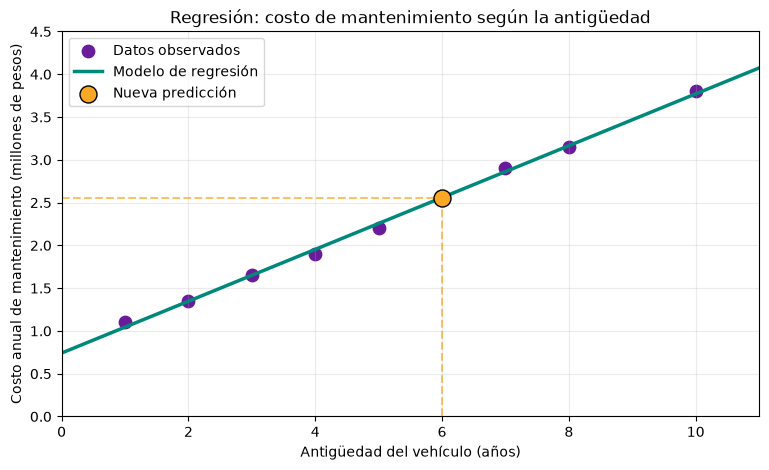

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Datos 
# X: antigüedad del vehículo en años
X = np.array([1, 2, 3, 4, 5, 7, 8, 10]).reshape(-1, 1)

# y: costo anual de mantenimiento en millones de pesos
y = np.array([1.10, 1.35, 1.65, 1.90, 2.20, 2.90, 3.15, 3.80])

modelo_regresion = LinearRegression()
modelo_regresion.fit(X, y)

intercepto = modelo_regresion.intercept_
pendiente = modelo_regresion.coef_[0]

print(f"Intercepto estimado: {intercepto:.3f}")
print(f"Pendiente estimada: {pendiente:.3f}")
print(
    f"Modelo ajustado: costo = "
    f"{intercepto:.3f} + {pendiente:.3f} × antigüedad"
)

antiguedad_nueva = np.array([[6]])
costo_predicho = modelo_regresion.predict(antiguedad_nueva)[0]

print(
    f"\nCosto estimado para un vehículo de 6 años: "
    f"${costo_predicho:.2f} millones"
)

# Valores para dibujar la recta de regresión
X_recta = np.linspace(0, 11, 200).reshape(-1, 1)
y_recta = modelo_regresion.predict(X_recta)

# Gráfica
plt.figure(figsize=(9, 5))

plt.scatter(
    X,
    y,
    color="#6A1B9A",
    s=80,
    label="Datos observados"
)

plt.plot(
    X_recta,
    y_recta,
    color="#00897B",
    linewidth=2.5,
    label="Modelo de regresión"
)

plt.scatter(
    antiguedad_nueva[0, 0],
    costo_predicho,
    color="#F9A825",
    s=150,
    edgecolor="black",
    zorder=3,
    label="Nueva predicción"
)

plt.vlines(
    antiguedad_nueva[0, 0],
    0,
    costo_predicho,
    colors="#F9A825",
    linestyles="--",
    alpha=0.7
)

plt.hlines(
    costo_predicho,
    0,
    antiguedad_nueva[0, 0],
    colors="#F9A825",
    linestyles="--",
    alpha=0.7
)

plt.title("Regresión: costo de mantenimiento según la antigüedad")
plt.xlabel("Antigüedad del vehículo (años)")
plt.ylabel("Costo anual de mantenimiento (millones de pesos)")
plt.xlim(0, 11)
plt.ylim(0, 4.5)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## Clasificación

La **clasificación** es una tarea de aprendizaje supervisado cuyo objetivo es asignar cada observación a una categoría o clase.

En este caso, la variable objetivo toma valores pertenecientes a un conjunto finito de categorías:

$$
y\in\mathcal{C},
$$

donde $\mathcal{C}$ representa el conjunto de clases posibles.

Por ejemplo, en un problema de detección de correos no deseados:

$$
\mathcal{C}
=
\left\{
\text{no spam},
\text{spam}
\right\}.
$$

Estas categorías pueden codificarse numéricamente:

$$
y=
\begin{cases}
0, & \text{si el correo no es spam},\\
1, & \text{si el correo es spam}.
\end{cases}
$$

Aunque se utilicen los números $0$ y $1$, estos valores representan **categorías**, no cantidades numéricas continuas.

## Tipos de clasificación

- **Clasificación binaria:** existen únicamente dos clases, como spam o no spam.
- **Clasificación multiclase:** existen tres o más clases, como clasificar una flor en una de varias especies.

## Ejemplos de problemas de clasificación

- Determinar si un correo es spam o no spam.
- Clasificar un tumor como benigno o maligno.
- Determinar si un cliente abandonará o no una empresa.
- Identificar la especie de una planta.
- Clasificar una transacción como legítima o fraudulenta.

## Frontera de decisión

El modelo aprende una regla que separa las observaciones pertenecientes a clases diferentes. Esta separación se denomina **frontera de decisión**.

En la clasificación binaria, algunos modelos estiman primero una probabilidad:

$$
P(y=1\mid\mathbf{x}).
$$

Posteriormente, la probabilidad se transforma en una categoría. Utilizando un umbral de $0.5$:

$$
\widehat{y}
=
\begin{cases}
1, & \text{si }P(y=1\mid\mathbf{x})\geq 0.5,\\
0, & \text{si }P(y=1\mid\mathbf{x})<0.5.
\end{cases}
$$

> **Idea:** en clasificación, la salida final del modelo es una categoría, aunque algunos algoritmos también proporcionen la probabilidad de pertenecer a cada clase.

Clase predicha: Spam
Probabilidad de no ser spam: 7.99%
Probabilidad de ser spam: 92.01%


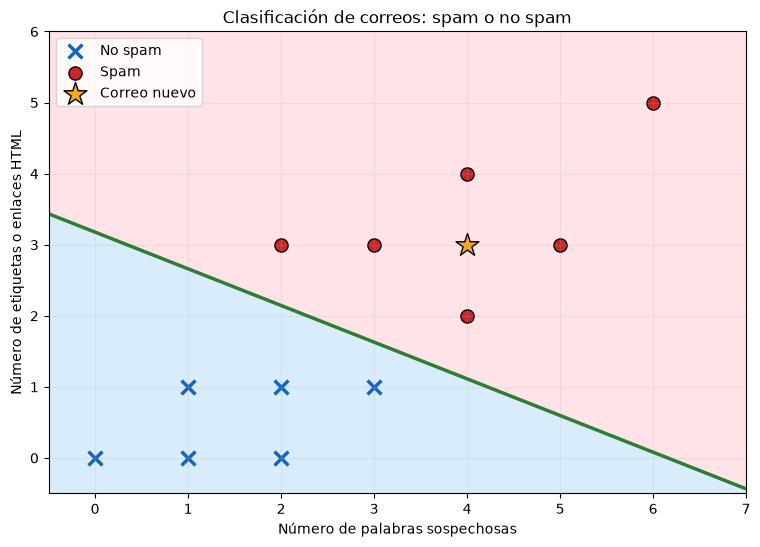

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Características de correos electrónicos:
# Columna 1: número de palabras sospechosas
# Columna 2: número de etiquetas o enlaces HTML
X = np.array([
    [0, 0],
    [1, 0],
    [1, 1],
    [2, 0],
    [2, 1],
    [3, 1],
    [2, 3],
    [3, 3],
    [4, 2],
    [4, 4],
    [5, 3],
    [6, 5]
])

# Variable objetivo:
# 0 = no spam
# 1 = spam
y = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

modelo_clasificacion = LogisticRegression()
modelo_clasificacion.fit(X, y)


correo_nuevo = np.array([[4, 3]])

# Predicción de la clase
clase_predicha = modelo_clasificacion.predict(correo_nuevo)[0]

# Probabilidades de las dos clases
probabilidades = modelo_clasificacion.predict_proba(correo_nuevo)[0]

etiqueta_predicha = "Spam" if clase_predicha == 1 else "No spam"

print(f"Clase predicha: {etiqueta_predicha}")
print(f"Probabilidad de no ser spam: {probabilidades[0]:.2%}")
print(f"Probabilidad de ser spam: {probabilidades[1]:.2%}")

x1_min, x1_max = -0.5, 7
x2_min, x2_max = -0.5, 6

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)

puntos_cuadricula = np.c_[xx1.ravel(), xx2.ravel()]

probabilidad_spam = modelo_clasificacion.predict_proba(
    puntos_cuadricula
)[:, 1].reshape(xx1.shape)

plt.figure(figsize=(9, 6))

plt.contourf(
    xx1,
    xx2,
    probabilidad_spam,
    levels=[0, 0.5, 1],
    colors=["#BBDEFB", "#FFCDD2"],
    alpha=0.55
)

# Frontera de decisión: probabilidad igual a 0.5
plt.contour(
    xx1,
    xx2,
    probabilidad_spam,
    levels=[0.5],
    colors=["#2E7D32"],
    linewidths=2.5
)

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    color="#1565C0",
    marker="x",
    s=100,
    linewidths=2.5,
    label="No spam"
)


plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    color="#C62828",
    marker="o",
    s=90,
    edgecolor="black",
    label="Spam"
)

plt.scatter(
    correo_nuevo[0, 0],
    correo_nuevo[0, 1],
    color="#F9A825",
    marker="*",
    s=300,
    edgecolor="black",
    label="Correo nuevo",
    zorder=4
)

plt.title("Clasificación de correos: spam o no spam")
plt.xlabel("Número de palabras sospechosas")
plt.ylabel("Número de etiquetas o enlaces HTML")
plt.xlim(x1_min, x1_max)
plt.ylim(x2_min, x2_max)
plt.grid(alpha=0.2)
plt.legend()
plt.show()


<center>
  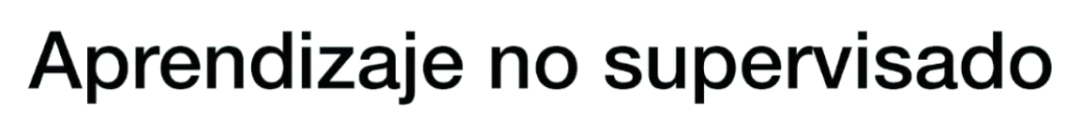
  </center>

## Aprendizaje no supervisado

El **aprendizaje no supervisado** reúne los métodos de Machine Learning que trabajan con observaciones que no tienen una respuesta o etiqueta conocida.

El conjunto de datos está formado únicamente por vectores de características:

$$
\mathcal{D}
=
\left\{
\mathbf{x}_i
\right\}_{i=1}^{n},
$$

donde cada observación contiene $p$ características:

$$
\mathbf{x}_i
=
\left(
x_{i1},x_{i2},\ldots,x_{ip}
\right)^{\mathsf{T}}.
$$

A diferencia del aprendizaje supervisado, no se dispone de una variable objetivo $y$. Por tanto, el propósito no es predecir una respuesta conocida, sino **descubrir estructuras, relaciones o patrones presentes en los datos**.

## Principales tareas del aprendizaje no supervisado

- **Agrupamiento o clustering:** formar grupos de observaciones similares.
- **Reducción de dimensionalidad:** representar los datos utilizando un número menor de variables.
- **Detección de anomalías:** identificar observaciones inusuales o alejadas del comportamiento general.
- **Reglas de asociación:** descubrir relaciones frecuentes entre variables o productos.

## Agrupamiento o clustering

El agrupamiento busca dividir las observaciones en grupos llamados **clústeres**, de manera que:

- Las observaciones pertenecientes al mismo clúster sean similares entre sí.
- Las observaciones pertenecientes a clústeres diferentes sean lo más distintas posible.

Por ejemplo, si cada correo electrónico se representa mediante:

$$
\mathbf{x}_i
=
\begin{pmatrix}
\text{número de palabras sospechosas}\\
\text{número de etiquetas o enlaces HTML}
\end{pmatrix},
$$

un algoritmo no supervisado podría descubrir dos o más grupos de correos con características diferentes, sin conocer previamente cuáles son spam y cuáles no.

## El algoritmo K-Means

**K-Means** es un algoritmo de agrupamiento que divide los datos en $K$ clústeres. Cada clúster está representado por un punto central llamado **centroide**.

El algoritmo busca minimizar la distancia de cada observación al centroide de su grupo:

$$
\min_{C_1,\ldots,C_K}
\sum_{k=1}^{K}
\sum_{\mathbf{x}_i\in C_k}
\left\|
\mathbf{x}_i-\boldsymbol{\mu}_k
\right\|^2,
$$

donde:

- $K$ es el número de clústeres.
- $C_k$ es el conjunto de observaciones del clúster $k$.
- $\boldsymbol{\mu}_k$ es el centroide del clúster $k$.
- $\left\|\mathbf{x}_i-\boldsymbol{\mu}_k\right\|^2$ mide la distancia entre una observación y su centroide.

## Diferencia con la clasificación

| Clasificación supervisada | Agrupamiento no supervisado |
|:---|:---|
| Utiliza categorías conocidas | No utiliza categorías conocidas |
| Aprende a predecir una etiqueta | Descubre grupos en los datos |
| Requiere una variable objetivo $y$ | Solamente utiliza las características $\mathbf{X}$ |
| Ejemplo: predecir spam o no spam | Ejemplo: encontrar grupos de correos similares |

> **Importante:** los números asignados a los clústeres, como clúster 0 y clúster 1, no son etiquetas conocidas ni tienen un significado automático. Es necesario analizar las características de cada grupo para interpretarlo.

Datos originales:


,palabras_sospechosas,etiquetas_html
0,0,0
1,1,0
2,1,1
3,2,0
4,2,1



Datos con el clúster asignado:


,palabras_sospechosas,etiquetas_html,cluster
0,0,0,0
1,1,0,0
2,1,1,0
3,2,0,0
4,2,1,0
5,3,1,0
6,1,2,0
7,2,2,0
8,4,5,1
9,5,4,1



Características promedio de los clústeres:


,numero_correos,promedio_palabras_sospechosas,promedio_etiquetas_html
cluster,,,
0,8,1.5,0.88
1,8,6.0,5.88


Centroides de los clústeres:
   palabras_sospechosas  etiquetas_html
0                   1.5            0.88
1                   6.0            5.88


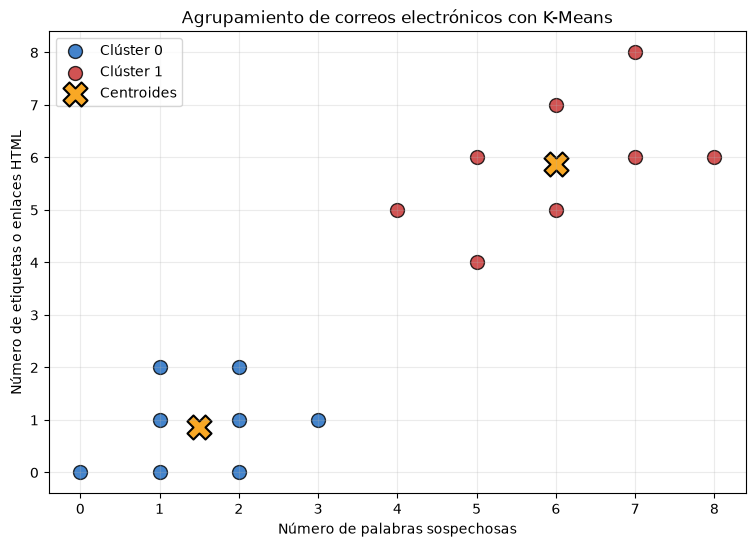

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------
# 1. Datos sin etiquetas
# --------------------------------------------------

# Cada fila representa un correo electrónico.
# Columna 1: número de palabras sospechosas
# Columna 2: número de etiquetas o enlaces HTML

X = np.array([
    [0, 0],
    [1, 0],
    [1, 1],
    [2, 0],
    [2, 1],
    [3, 1],
    [1, 2],
    [2, 2],
    [4, 5],
    [5, 4],
    [5, 6],
    [6, 5],
    [7, 6],
    [6, 7],
    [8, 6],
    [7, 8]
])

datos = pd.DataFrame(
    X,
    columns=[
        "palabras_sospechosas",
        "etiquetas_html"
    ]
)

print("Datos originales:")
display(datos.head())


escalador = StandardScaler()
X_estandarizado = escalador.fit_transform(X)

# --------------------------------------------------
# 3. Aplicación del algoritmo K-Means
# --------------------------------------------------

modelo_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# fit_predict entrena el modelo y asigna un clúster
# a cada observación.
cluster = modelo_kmeans.fit_predict(X_estandarizado)

datos["cluster"] = cluster

print("\nDatos con el clúster asignado:")
display(datos)


resumen_clusters = datos.groupby("cluster").agg(
    numero_correos=("cluster", "size"),
    promedio_palabras_sospechosas=(
        "palabras_sospechosas",
        "mean"
    ),
    promedio_etiquetas_html=(
        "etiquetas_html",
        "mean"
    )
)

print("\nCaracterísticas promedio de los clústeres:")
display(resumen_clusters.round(2))

centroides_originales = escalador.inverse_transform(
    modelo_kmeans.cluster_centers_
)

print("Centroides de los clústeres:")
print(
    pd.DataFrame(
        centroides_originales,
        columns=[
            "palabras_sospechosas",
            "etiquetas_html"
        ]
    ).round(2)
)

plt.figure(figsize=(9, 6))

colores = ["#1565C0", "#C62828"]

for k in range(2):
    plt.scatter(
        X[cluster == k, 0],
        X[cluster == k, 1],
        color=colores[k],
        s=100,
        edgecolor="black",
        alpha=0.8,
        label=f"Clúster {k}"
    )

#  centroides
plt.scatter(
    centroides_originales[:, 0],
    centroides_originales[:, 1],
    color="#F9A825",
    marker="X",
    s=300,
    edgecolor="black",
    linewidth=1.5,
    label="Centroides"
)

plt.title("Agrupamiento de correos electrónicos con K-Means")
plt.xlabel("Número de palabras sospechosas")
plt.ylabel("Número de etiquetas o enlaces HTML")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

<center>
  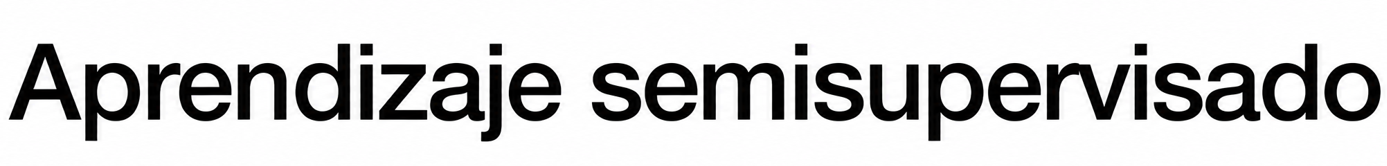
</center>

## Aprendizaje semisupervisado

El **aprendizaje semisupervisado** combina elementos del aprendizaje supervisado y del aprendizaje no supervisado.

En este paradigma se dispone de:

- Una pequeña cantidad de observaciones **etiquetadas**.
- Una gran cantidad de observaciones **sin etiquetar**.

El objetivo es utilizar la estructura presente en los datos sin etiquetar para mejorar el aprendizaje obtenido a partir de las pocas observaciones etiquetadas.

## Formulación matemática

El conjunto de datos etiquetados puede representarse como:

$$
\mathcal{D}_{L}
=
\left\{
(\mathbf{x}_i,y_i)
\right\}_{i=1}^{\ell},
$$

donde:

- $\mathbf{x}_i$ contiene las características de la observación.
- $y_i$ es su etiqueta conocida.
- $\ell$ es el número de observaciones etiquetadas.

También se dispone de un conjunto de datos sin etiquetar:

$$
\mathcal{D}_{U}
=
\left\{
\mathbf{x}_j
\right\}_{j=\ell+1}^{n}.
$$

Generalmente, la cantidad de datos etiquetados es mucho menor que la cantidad de datos disponibles:

$$
\ell\ll n.
$$

El algoritmo utiliza conjuntamente los dos conjuntos:

$$
\widehat{f}
=
\mathcal{A}
\left(
\mathcal{D}_{L},
\mathcal{D}_{U}
\right),
$$

donde $\mathcal{A}$ representa el algoritmo de aprendizaje y $\widehat{f}$ es el modelo obtenido.

## ¿Por qué utilizar aprendizaje semisupervisado?

En muchos problemas es fácil obtener grandes cantidades de datos, pero asignarles una etiqueta correcta puede ser costoso, lento o requerir conocimiento especializado.

Por ejemplo:

- Es fácil recopilar miles de correos electrónicos, pero una persona debe revisarlos para determinar si son spam.
- Es fácil almacenar imágenes médicas, pero un especialista debe analizarlas para establecer un diagnóstico.
- Es fácil obtener grabaciones de voz, pero transcribirlas manualmente requiere mucho tiempo.
- Es fácil recopilar fotografías, pero etiquetar todos los objetos presentes puede ser costoso.

## Ejemplo 

Supongamos que se tienen $1\,000$ correos electrónicos:

- $50$ fueron revisados y etiquetados como **spam** o **no spam**.
- $950$ no tienen una etiqueta conocida.

El aprendizaje supervisado utilizaría únicamente los $50$ correos etiquetados. En cambio, el aprendizaje semisupervisado intenta aprovechar también la distribución y las semejanzas presentes en los otros $950$ correos.

## Supuesto fundamental

Muchos métodos semisupervisados se basan en la siguiente idea:

> Las observaciones que se encuentran próximas entre sí o que tienen características similares probablemente pertenezcan a la misma clase.

Este supuesto permite transferir o propagar las etiquetas conocidas hacia observaciones similares que todavía no tienen etiqueta.

## Métodos semisupervisados frecuentes

- **Propagación de etiquetas:** transfiere las etiquetas a través de la estructura de proximidad de los datos.
- **Difusión de etiquetas:** distribuye gradualmente la información de las etiquetas conocidas.
- **Pseudoetiquetado:** un modelo asigna etiquetas provisionales a los datos sin etiquetar.
- **Autoentrenamiento:** el modelo se vuelve a entrenar incorporando sus predicciones más confiables.

## Comparación de los paradigmas

| Paradigma | Datos etiquetados | Datos sin etiquetar | Objetivo principal |
|:---|:---:|:---:|:---|
| **Supervisado** | Muchos o todos | No son necesarios | Predecir una respuesta conocida |
| **No supervisado** | Ninguno | Todos | Descubrir patrones o grupos |
| **Semisupervisado** | Pocos | Muchos | Mejorar la clasificación utilizando ambos tipos de datos |

> **Idea:** el aprendizaje semisupervisado es útil cuando existen muchos datos disponibles, pero obtener sus etiquetas resulta difícil o costoso.

Número total de observaciones: 250
Observaciones etiquetadas: 10
Observaciones sin etiquetar: 240

Cantidad asignada a cada clase:
Clase 0: 139 observaciones
Clase 1: 111 observaciones

Exactitud sobre las etiquetas ocultas: 86.67%


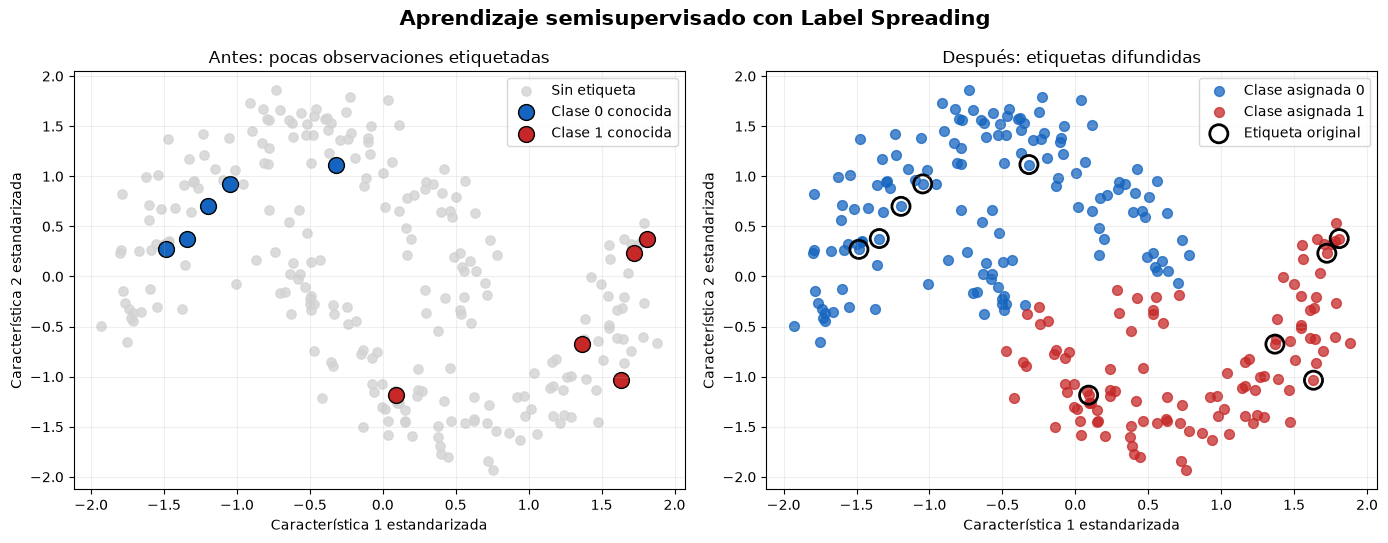

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.semi_supervised import LabelSpreading
from sklearn.metrics import accuracy_score



X, y_real = make_moons(
    n_samples=250,
    noise=0.12,
    random_state=42
)

escalador = StandardScaler()
X_estandarizado = escalador.fit_transform(X)


rng = np.random.default_rng(42)

# En Scikit-Learn, el valor -1 indica que una
# observación no tiene una etiqueta conocida.
y_parcial = np.full(
    shape=len(y_real),
    fill_value=-1,
    dtype=int
)

indices_clase_0 = np.where(y_real == 0)[0]
indices_clase_1 = np.where(y_real == 1)[0]

etiquetados_clase_0 = rng.choice(
    indices_clase_0,
    size=5,
    replace=False
)

etiquetados_clase_1 = rng.choice(
    indices_clase_1,
    size=5,
    replace=False
)

indices_etiquetados = np.concatenate([
    etiquetados_clase_0,
    etiquetados_clase_1
])

y_parcial[indices_etiquetados] = y_real[indices_etiquetados]

# Máscaras para identificar los dos tipos de datos
tiene_etiqueta = y_parcial != -1
sin_etiqueta = y_parcial == -1

print(f"Número total de observaciones: {len(X)}")
print(f"Observaciones etiquetadas: {tiene_etiqueta.sum()}")
print(f"Observaciones sin etiquetar: {sin_etiqueta.sum()}")

# --------------------------------------------------
# 3. Entrenar el modelo semisupervisado
# --------------------------------------------------

modelo_semisupervisado = LabelSpreading(
    kernel="knn",
    n_neighbors=7,
    alpha=0.2,
    max_iter=1000
)

modelo_semisupervisado.fit(
    X_estandarizado,
    y_parcial
)

# Etiquetas propagadas a todas las observaciones
y_propagada = modelo_semisupervisado.transduction_

# --------------------------------------------------
# 4. Revisar el resultado
# --------------------------------------------------

print("\nCantidad asignada a cada clase:")

clases, cantidades = np.unique(
    y_propagada,
    return_counts=True
)

for clase, cantidad in zip(clases, cantidades):
    print(f"Clase {clase}: {cantidad} observaciones")

# Como los datos son simulados, conocemos las etiquetas
# ocultas y podemos verificar qué tan bien se propagaron.
exactitud_no_etiquetados = accuracy_score(
    y_real[sin_etiqueta],
    y_propagada[sin_etiqueta]
)

print(
    "\nExactitud sobre las etiquetas ocultas: "
    f"{exactitud_no_etiquetados:.2%}"
)

# --------------------------------------------------
# 5. Visualización
# --------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.5)
)

# Gráfica 1: situación inicial
axes[0].scatter(
    X_estandarizado[sin_etiqueta, 0],
    X_estandarizado[sin_etiqueta, 1],
    color="lightgray",
    s=45,
    alpha=0.8,
    label="Sin etiqueta"
)

axes[0].scatter(
    X_estandarizado[
        tiene_etiqueta & (y_parcial == 0), 0
    ],
    X_estandarizado[
        tiene_etiqueta & (y_parcial == 0), 1
    ],
    color="#1565C0",
    s=130,
    edgecolor="black",
    label="Clase 0 conocida"
)

axes[0].scatter(
    X_estandarizado[
        tiene_etiqueta & (y_parcial == 1), 0
    ],
    X_estandarizado[
        tiene_etiqueta & (y_parcial == 1), 1
    ],
    color="#C62828",
    s=130,
    edgecolor="black",
    label="Clase 1 conocida"
)

axes[0].set_title("Antes: pocas observaciones etiquetadas")
axes[0].set_xlabel("Característica 1 estandarizada")
axes[0].set_ylabel("Característica 2 estandarizada")
axes[0].grid(alpha=0.2)
axes[0].legend()

# Gráfica 2: etiquetas propagadas
colores = ["#1565C0", "#C62828"]

for clase, color in enumerate(colores):
    axes[1].scatter(
        X_estandarizado[y_propagada == clase, 0],
        X_estandarizado[y_propagada == clase, 1],
        color=color,
        s=50,
        alpha=0.75,
        label=f"Clase asignada {clase}"
    )

# Resaltar las pocas observaciones originalmente etiquetadas
axes[1].scatter(
    X_estandarizado[tiene_etiqueta, 0],
    X_estandarizado[tiene_etiqueta, 1],
    facecolors="none",
    edgecolors="black",
    s=170,
    linewidths=2,
    label="Etiqueta original"
)

axes[1].set_title("Después: etiquetas difundidas")
axes[1].set_xlabel("Característica 1 estandarizada")
axes[1].set_ylabel("Característica 2 estandarizada")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.suptitle(
    "Aprendizaje semisupervisado con Label Spreading",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

<center>
  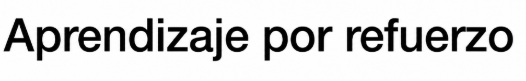
</center>


## Aprendizaje por refuerzo

El **aprendizaje por refuerzo** es un paradigma de Machine Learning en el que un agente aprende a tomar decisiones mediante la interacción repetida con un entorno.

En cada instante, el agente:

1. Observa el estado actual del entorno.
2. Selecciona una acción.
3. El entorno cambia como consecuencia de esa acción.
4. El agente recibe una recompensa o penalización.
5. Utiliza esa experiencia para mejorar sus decisiones futuras.

A diferencia del aprendizaje supervisado, el agente no recibe la respuesta correcta para cada situación. En su lugar, debe descubrir qué acciones producen las mayores recompensas a largo plazo.

### Elementos principales

| Elemento | Símbolo | Descripción |
|:---|:---:|:---|
| **Agente** | — | Entidad que aprende y toma decisiones |
| **Entorno** | — | Sistema con el que interactúa el agente |
| **Estado** | $s_t$ | Situación del entorno en el instante $t$ |
| **Acción** | $a_t$ | Decisión tomada por el agente |
| **Recompensa** | $r_{t+1}$ | Valor recibido después de ejecutar una acción |
| **Política** | $\pi$ | Regla utilizada para seleccionar acciones |
| **Episodio** | — | Secuencia completa desde el inicio hasta un estado terminal |

### Ciclo de interacción

En el instante $t$, el agente observa el estado $s_t$ y selecciona una acción:

$$
a_t\sim\pi(\,\cdot\mid s_t).
$$

Después de ejecutar la acción, el entorno produce:

- Un nuevo estado $s_{t+1}$.
- Una recompensa $r_{t+1}$.

La interacción puede representarse como:

$$
s_t
\longrightarrow
a_t
\longrightarrow
r_{t+1}
\longrightarrow
s_{t+1}.
$$

### Objetivo del agente

El objetivo no consiste necesariamente en obtener la mayor recompensa inmediata, sino en maximizar la suma de las recompensas futuras.

El retorno acumulado desde el instante $t$ se define como:

$$
G_t
=
r_{t+1}
+
\gamma r_{t+2}
+
\gamma^2r_{t+3}
+\cdots,
$$

o de forma compacta:

$$
G_t
=
\sum_{k=0}^{\infty}
\gamma^k r_{t+k+1},
$$

donde $\gamma$ es el **factor de descuento**:

$$
0\leq\gamma\leq1.
$$

- Si $\gamma$ está cerca de $0$, el agente prioriza las recompensas inmediatas.
- Si $\gamma$ está cerca de $1$, el agente concede mayor importancia a las recompensas futuras.

### Política

La política $\pi$ representa el comportamiento del agente. Especifica qué acción debe seleccionar en cada estado:

$$
\pi(a\mid s)
=
P(A_t=a\mid S_t=s).
$$

Una política determinista puede expresarse como:

$$
a=\pi(s).
$$

El propósito del aprendizaje es encontrar una política óptima $\pi^*$ que maximice la recompensa acumulada esperada.

### Exploración y explotación

Durante el aprendizaje, el agente debe equilibrar dos comportamientos:

- **Exploración:** probar acciones nuevas para descubrir sus consecuencias.
- **Explotación:** seleccionar la mejor acción conocida hasta el momento.

Si el agente solamente explota, podría mantener una estrategia que parece buena, pero que no es realmente la mejor. Si solamente explora, nunca aprovechará adecuadamente lo aprendido.

### Q-Learning

**Q-Learning** es un algoritmo de aprendizaje por refuerzo que aprende el valor de ejecutar una acción $a$ cuando el agente se encuentra en un estado $s$.

Este valor se representa mediante:

$$
Q(s,a).
$$

La regla de actualización es:

$$
Q(s_t,a_t)
\leftarrow
Q(s_t,a_t)
+
\alpha
\left[
r_{t+1}
+
\gamma\max_a Q(s_{t+1},a)
-
Q(s_t,a_t)
\right],
$$

donde:

- $\alpha$ es la tasa de aprendizaje.
- $\gamma$ es el factor de descuento.
- $r_{t+1}$ es la recompensa recibida.
- $\max_a Q(s_{t+1},a)$ es el mejor valor futuro estimado.
- La expresión entre corchetes representa el error de aprendizaje.

Una vez aprendidos los valores $Q(s,a)$, la acción elegida en cada estado es:

$$
\pi(s)
=
\underset{a}{\operatorname{arg\,max}}\;Q(s,a).
$$

### Ejemplos de aplicación

- Enseñar a un robot a desplazarse.
- Desarrollar agentes capaces de jugar videojuegos.
- Controlar semáforos de manera dinámica.
- Optimizar rutas de distribución.
- Administrar inventarios.
- Personalizar recomendaciones.
- Diseñar estrategias de control industrial.

### Comparación con otros paradigmas

| Paradigma | Información utilizada | Objetivo |
|:---|:---|:---|
| **Supervisado** | Ejemplos con respuestas conocidas | Predecir una variable objetivo |
| **No supervisado** | Datos sin etiquetas | Descubrir estructuras o patrones |
| **Semisupervisado** | Pocos datos etiquetados y muchos sin etiquetar | Aprovechar ambos tipos de información |
| **Por refuerzo** | Recompensas obtenidas al interactuar | Aprender una estrategia de decisión |

> **Idea clave:** en el aprendizaje por refuerzo, el agente aprende mediante prueba y error. Una acción no se evalúa únicamente por su resultado inmediato, sino también por las consecuencias que puede producir en el futuro.

Tabla Q aprendida:

Estado | Izquierda | Derecha | Mejor acción
  0    |   6.821   |  7.285  |      →      
  1    |   6.821   |  7.774  |      →      
  2    |   7.285   |  8.288  |      →      
  3    |   7.774   |  8.830  |      →      
  4    |   8.288   |  9.400  |      →      
  5    |   8.830   | 10.000  |      →      
  6    |   0.000   |  0.000  |     META    

Ruta aprendida por el agente:
0 → 1 → 2 → 3 → 4 → 5 → 6


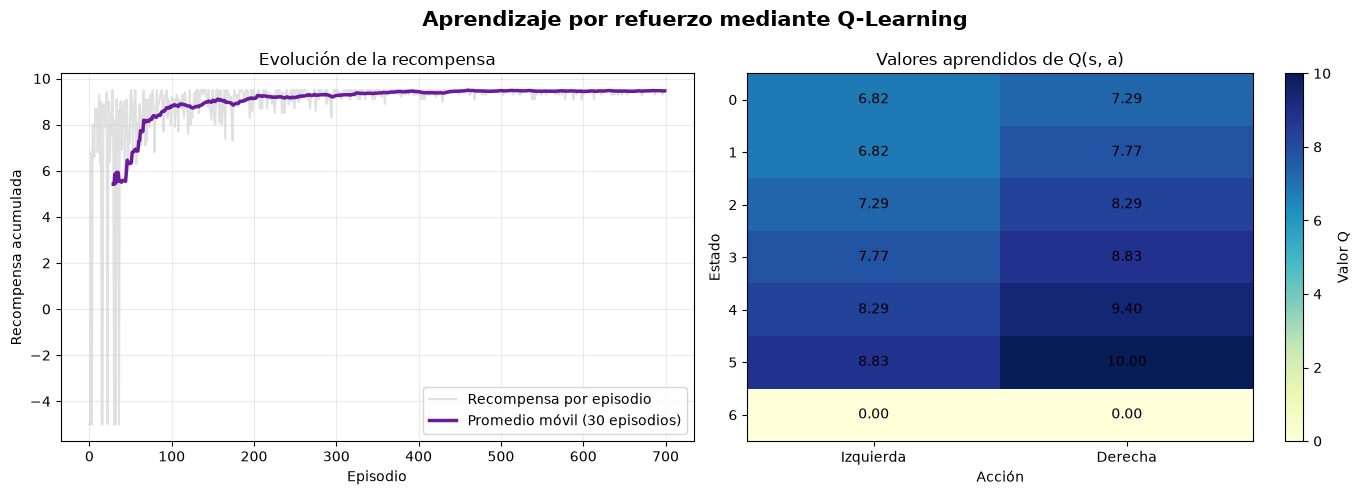

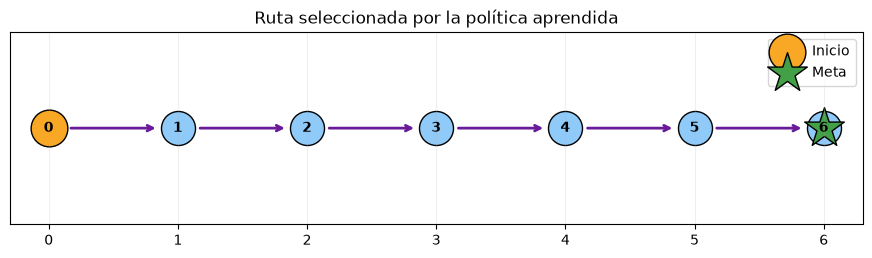

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# El pasillo tiene 7 posiciones:
#
# Inicio                                  Meta
#   0       1       2       3       4       5       6
#  [A]     [ ]     [ ]     [ ]     [ ]     [ ]     [M]
#
# Acciones:
# 0 = moverse a la izquierda
# 1 = moverse a la derecha

numero_estados = 7
numero_acciones = 2

estado_inicial = 0
estado_meta = 6

acciones = {
    0: "←",
    1: "→"
}

# Parámetros de Q-Learning

alpha = 0.20       # Tasa de aprendizaje
gamma = 0.95       # Factor de descuento
epsilon = 1.00     # Probabilidad inicial de exploración
epsilon_min = 0.05
decaimiento = 0.995

numero_episodios = 700
maximo_pasos = 50

# Inicializar la tabla Q con ceros
Q = np.zeros(
    (numero_estados, numero_acciones)
)

# Generador de números aleatorios reproducible
rng = np.random.default_rng(42)

recompensas_por_episodio = []

# Función que representa el entorno
def ejecutar_accion(estado, accion):
    """
    Ejecuta una acción y devuelve:
    nuevo_estado, recompensa, finalizado.
    """

    if accion == 0:
        # El agente se mueve a la izquierda
        nuevo_estado = max(0, estado - 1)
    else:
        # El agente se mueve a la derecha
        nuevo_estado = min(
            numero_estados - 1,
            estado + 1
        )

    # Verificar si alcanzó la meta
    finalizado = nuevo_estado == estado_meta

    if finalizado:
        recompensa = 10.0
    else:
        # Pequeña penalización para incentivar rutas cortas
        recompensa = -0.1

    return nuevo_estado, recompensa, finalizado

# Entrenamiento del agente
for episodio in range(numero_episodios):

    estado = estado_inicial
    recompensa_acumulada = 0

    for paso in range(maximo_pasos):

        # Estrategia epsilon-greedy:
        # explorar con probabilidad epsilon
        if rng.random() < epsilon:
            accion = rng.integers(numero_acciones)

        # explotar el conocimiento actual
        else:
            accion = np.argmax(Q[estado])

        # Interacción con el entorno
        nuevo_estado, recompensa, finalizado = (
            ejecutar_accion(estado, accion)
        )

        # Valor objetivo de Q-Learning
        if finalizado:
            objetivo = recompensa
        else:
            objetivo = (
                recompensa
                + gamma * np.max(Q[nuevo_estado])
            )

        # Actualización de la tabla Q
        Q[estado, accion] = (
            Q[estado, accion]
            + alpha
            * (
                objetivo
                - Q[estado, accion]
            )
        )

        estado = nuevo_estado
        recompensa_acumulada += recompensa

        if finalizado:
            break

    recompensas_por_episodio.append(
        recompensa_acumulada
    )

    # Reducir gradualmente la exploración
    epsilon = max(
        epsilon_min,
        epsilon * decaimiento
    )

# Política aprendida
politica = np.argmax(
    Q,
    axis=1
)

print("Tabla Q aprendida:\n")
print(
    "Estado | Izquierda | Derecha | Mejor acción"
)

for estado in range(numero_estados):

    if estado == estado_meta:
        mejor_accion = "META"
    else:
        mejor_accion = acciones[politica[estado]]

    print(
        f"{estado:^6} | "
        f"{Q[estado, 0]:^9.3f} | "
        f"{Q[estado, 1]:^7.3f} | "
        f"{mejor_accion:^12}"
    )

# política aprendida

estado = estado_inicial
ruta_aprendida = [estado]

for _ in range(maximo_pasos):

    if estado == estado_meta:
        break

    accion = politica[estado]

    estado, _, finalizado = ejecutar_accion(
        estado,
        accion
    )

    ruta_aprendida.append(estado)

    if finalizado:
        break

print("\nRuta aprendida por el agente:")
print(" → ".join(map(str, ruta_aprendida)))


# Visualización del aprendizaje

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Promedio móvil de las recompensas
ventana = 30

promedio_movil = np.convolve(
    recompensas_por_episodio,
    np.ones(ventana) / ventana,
    mode="valid"
)

axes[0].plot(
    recompensas_por_episodio,
    color="lightgray",
    alpha=0.7,
    label="Recompensa por episodio"
)

axes[0].plot(
    range(
        ventana - 1,
        numero_episodios
    ),
    promedio_movil,
    color="#6A1B9A",
    linewidth=2.5,
    label=f"Promedio móvil ({ventana} episodios)"
)

axes[0].set_title("Evolución de la recompensa")
axes[0].set_xlabel("Episodio")
axes[0].set_ylabel("Recompensa acumulada")
axes[0].grid(alpha=0.25)
axes[0].legend()

# Mapa de calor de la tabla Q
imagen = axes[1].imshow(
    Q,
    cmap="YlGnBu",
    aspect="auto"
)

axes[1].set_title("Valores aprendidos de Q(s, a)")
axes[1].set_xlabel("Acción")
axes[1].set_ylabel("Estado")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(
    ["Izquierda", "Derecha"]
)
axes[1].set_yticks(
    range(numero_estados)
)

# Mostrar los valores dentro del mapa
for estado in range(numero_estados):
    for accion in range(numero_acciones):
        axes[1].text(
            accion,
            estado,
            f"{Q[estado, accion]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.colorbar(
    imagen,
    ax=axes[1],
    label="Valor Q"
)

plt.suptitle(
    "Aprendizaje por refuerzo mediante Q-Learning",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Visualización

plt.figure(figsize=(11, 2.5))

posiciones = np.arange(numero_estados)

plt.scatter(
    posiciones,
    np.zeros(numero_estados),
    color="#90CAF9",
    s=600,
    edgecolor="black"
)

plt.scatter(
    estado_inicial,
    0,
    color="#F9A825",
    s=700,
    edgecolor="black",
    label="Inicio"
)

plt.scatter(
    estado_meta,
    0,
    color="#43A047",
    marker="*",
    s=900,
    edgecolor="black",
    label="Meta"
)

for posicion in posiciones:
    plt.text(
        posicion,
        0,
        str(posicion),
        ha="center",
        va="center",
        fontweight="bold"
    )

for inicio, fin in zip(
    ruta_aprendida[:-1],
    ruta_aprendida[1:]
):
    plt.annotate(
        "",
        xy=(fin - 0.15, 0),
        xytext=(inicio + 0.15, 0),
        arrowprops={
            "arrowstyle": "->",
            "color": "#6A1B9A",
            "lw": 2
        }
    )

plt.title("Ruta seleccionada por la política aprendida")
plt.yticks([])
plt.xticks(posiciones)
plt.ylim(-0.5, 0.5)
plt.grid(axis="x", alpha=0.2)
plt.legend()
plt.show()

## 1.4 El verdadero objetivo: generalizar

- **Subajuste (*underfitting*):** el modelo es demasiado simple y falla incluso en entrenamiento.
- **Ajuste adecuado:** captura patrones que se reproducen en datos nuevos.
- **Sobreajuste (*overfitting*):** memoriza peculiaridades o ruido del entrenamiento y pierde desempeño fuera de la muestra.

La evaluación sobre los mismos datos usados para aprender produce una estimación optimista. Por eso reservamos un conjunto de **prueba**.

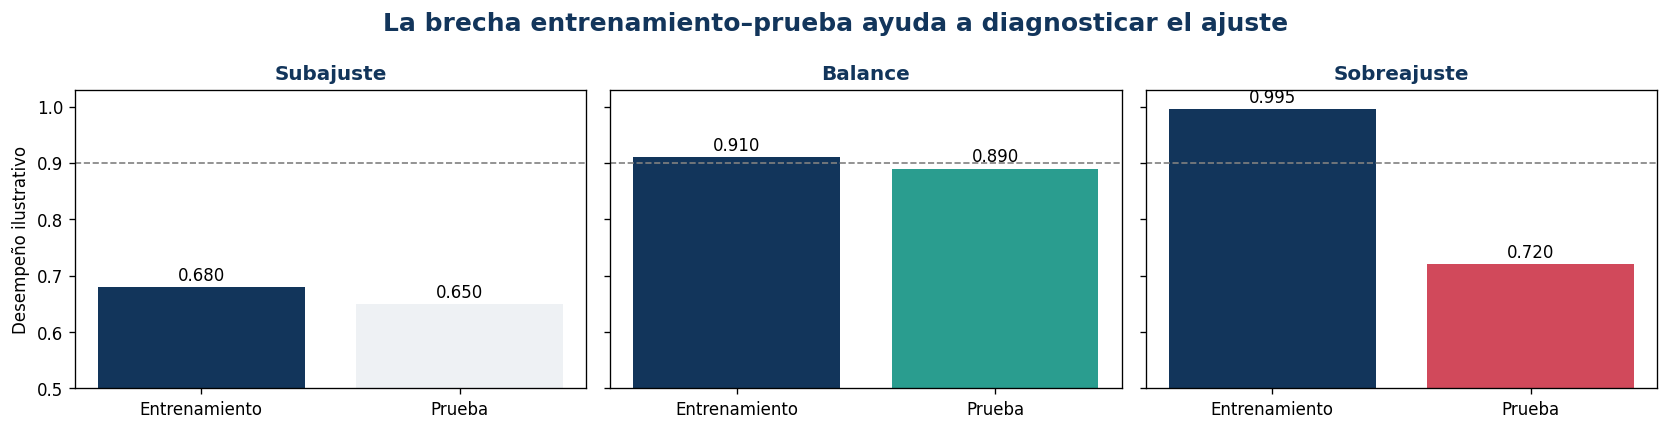

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
titulos = ["Subajuste", "Balance", "Sobreajuste"]
train = [0.68, 0.91, 0.995]
test = [0.65, 0.89, 0.72]
colores = [GRIS, VERDE, ROJO]

for ax, titulo, tr, te, color in zip(axes, titulos, train, test, colores):
    ax.bar(["Entrenamiento", "Prueba"], [tr, te], color=[AZUL, color])
    ax.set_ylim(0.5, 1.03)
    ax.set_title(titulo, fontweight="bold", color=AZUL)
    ax.axhline(0.9, color="gray", linestyle="--", linewidth=1)
    for j, v in enumerate([tr, te]):
        ax.text(j, v + 0.012, f"{v:.3f}", ha="center", fontsize=10)
axes[0].set_ylabel("Desempeño ilustrativo")
fig.suptitle("La brecha entrenamiento–prueba ayuda a diagnosticar el ajuste",
             fontsize=15, fontweight="bold", color=AZUL)
plt.tight_layout()
plt.show()

## 1.5 Flujo de trabajo supervisado

1. Formular la pregunta y definir la unidad de análisis.
2. Comprender la procedencia y calidad de los datos.
3. Separar entrenamiento y prueba.
4. Aprender el preprocesamiento **solo con entrenamiento**.
5. Ajustar el modelo.
6. Validar, elegir métricas y revisar errores.
7. Evaluar una sola vez en prueba.
8. Comunicar resultados, limitaciones y decisión.

> **Fuga de información (*data leakage*):** ocurre cuando el entrenamiento usa información que no estaría disponible al momento de predecir. Ajustar un escalador con todo el conjunto antes de separarlo es un ejemplo.

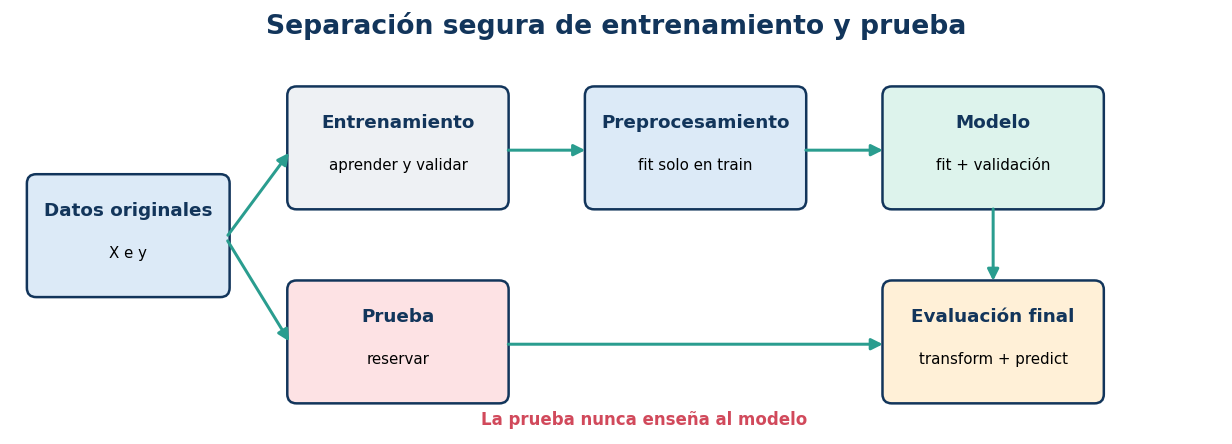

In [3]:
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.set_xlim(0, 13)
ax.set_ylim(0, 4.2)
ax.axis("off")

def caja(ax, x, y, w, h, titulo, texto, color):
    patch = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.04,rounding_size=0.1",
                           facecolor=color, edgecolor=AZUL, linewidth=1.5)
    ax.add_patch(patch)
    ax.text(x+w/2, y+h*0.67, titulo, ha="center", fontweight="bold", color=AZUL, fontsize=11)
    ax.text(x+w/2, y+h*0.31, texto, ha="center", fontsize=9)

caja(ax, 0.2, 1.5, 2.1, 1.25, "Datos originales", "X e y", AZUL_CLARO)
caja(ax, 3.0, 2.45, 2.3, 1.25, "Entrenamiento", "aprender y validar", GRIS)
caja(ax, 3.0, 0.35, 2.3, 1.25, "Prueba", "reservar", "#FDE2E4")
caja(ax, 6.2, 2.45, 2.3, 1.25, "Preprocesamiento", "fit solo en train", AZUL_CLARO)
caja(ax, 9.4, 2.45, 2.3, 1.25, "Modelo", "fit + validación", "#DDF3EC")
caja(ax, 9.4, 0.35, 2.3, 1.25, "Evaluación final", "transform + predict", "#FFF0D7")

flechas = [((2.3,2.1),(3.0,3.05)), ((2.3,2.1),(3.0,0.95)),
           ((5.3,3.05),(6.2,3.05)), ((8.5,3.05),(9.4,3.05)),
           ((5.3,0.95),(9.4,0.95)), ((10.55,2.45),(10.55,1.6))]
for inicio, fin in flechas:
    ax.add_patch(FancyArrowPatch(inicio, fin, arrowstyle="-|>", mutation_scale=14,
                                 color=VERDE, linewidth=1.8))
ax.text(6.8, 0.08, "La prueba nunca enseña al modelo", color=ROJO,
        fontweight="bold", ha="center")
ax.set_title("Separación segura de entrenamiento y prueba", fontsize=16,
             fontweight="bold", color=AZUL)
plt.show()

# 2. Preparación del entorno

El notebook usa `NumPy`, `Pandas`, `Matplotlib`, `Seaborn`, `StatsModels` y `Scikit-Learn`.

Si una biblioteca no está instalada, ejecute en una celda independiente:

```python
%pip install numpy pandas matplotlib seaborn statsmodels scikit-learn
```

Después reinicie el *kernel* y ejecute el notebook desde el comienzo.

In [4]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.datasets import load_breast_cancer, load_iris, load_wine
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

try:
    import statsmodels
    import statsmodels.api as sm
    STATSMODELS_AVAILABLE = True
except ModuleNotFoundError:
    statsmodels = None
    sm = None
    STATSMODELS_AVAILABLE = False

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(42)
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "figure.dpi": 110,
})

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-Learn:", sklearn.__version__)
print("StatsModels:", statsmodels.__version__ if STATSMODELS_AVAILABLE else "no disponible en este entorno")

Python: 3.12.13
,NumPy: 2.3.5
,Pandas: 2.2.3
,Matplotlib: 3.10.8
,Scikit-Learn: 1.8.0
,StatsModels: no disponible en este entorno


# 3. Caso de estudio: apoyo a la clasificación de tumores

**Pregunta analítica:** ¿podemos usar mediciones calculadas sobre imágenes digitalizadas de una masa mamaria para estimar si un caso pertenece a la clase maligna o benigna?

El conjunto **Breast Cancer Wisconsin (Diagnostic)** contiene 569 observaciones y 30 características numéricas derivadas de núcleos celulares. En la fuente incluida en Scikit-Learn, el objetivo original usa `0 = malignant` y `1 = benign`. Para que la clase positiva corresponda al evento prioritario, crearemos:

\[
y=1 \quad \text{si el caso es maligno}, \qquad y=0 \quad \text{si es benigno}.
\]

In [5]:
cancer = load_breast_cancer(as_frame=True)
X = cancer.data.copy()
y = (1 - cancer.target).rename("maligno")

df_cancer = X.copy()
df_cancer["maligno"] = y
df_cancer["diagnostico"] = y.map({0: "Benigno", 1: "Maligno"})

print("Dimensión de X:", X.shape)
print("Número de clases:", y.nunique())
print("Valores faltantes:", int(X.isna().sum().sum()))
print("Duplicados exactos:", int(df_cancer.duplicated().sum()))
print("\nPrimeras cinco variables:", list(X.columns[:5]))
print("\nMuestra reproducible:")
print(df_cancer.sample(5, random_state=42).iloc[:, [0, 1, 2, 3, -2, -1]].to_string())

Dimensión de X: (569, 30)
,Número de clases: 2
,Valores faltantes: 0
,Duplicados exactos: 0
,
,Primeras cinco variables: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
,
,Muestra reproducible:
,     mean radius  mean texture  mean perimeter  mean area  maligno diagnostico
,204        12.47         18.60           81.09      481.9        0     Benigno
,70         18.94         21.31          123.60     1130.0        1     Maligno
,131        15.46         19.48          101.70      748.9        1     Maligno
,431        12.40         17.68           81.47      467.8        0     Benigno
,540        11.54         14.44           74.65      402.9        0     Benigno


## 3.1 Comprensión de los datos antes de modelar

Preguntas mínimas:

- ¿Qué representa una fila?
- ¿Cómo se obtuvo la etiqueta?
- ¿Existen faltantes, duplicados o valores imposibles?
- ¿Las clases están balanceadas?
- ¿Las variables tienen escalas comparables?
- ¿La muestra representa la población donde se usará el modelo?

Un modelo puede ejecutar sin errores y aun así responder una pregunta equivocada. **Validar antes de interpretar**.

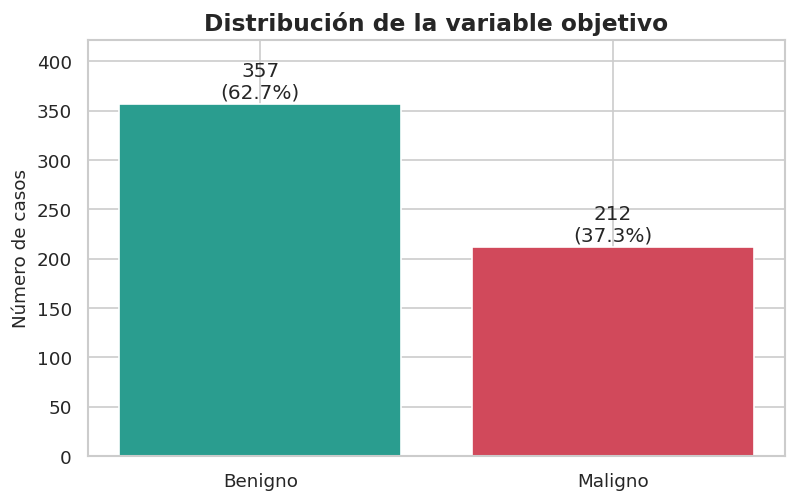

In [6]:
conteo = df_cancer["diagnostico"].value_counts().reindex(["Benigno", "Maligno"])
porcentaje = 100 * conteo / conteo.sum()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
barras = ax.bar(conteo.index, conteo.values, color=[VERDE, ROJO])
ax.set_title("Distribución de la variable objetivo")
ax.set_ylabel("Número de casos")
for barra, n, p in zip(barras, conteo.values, porcentaje.values):
    ax.text(barra.get_x() + barra.get_width()/2, n + 6, f"{n}\n({p:.1f}%)", ha="center")
ax.set_ylim(0, conteo.max()*1.18)
plt.show()

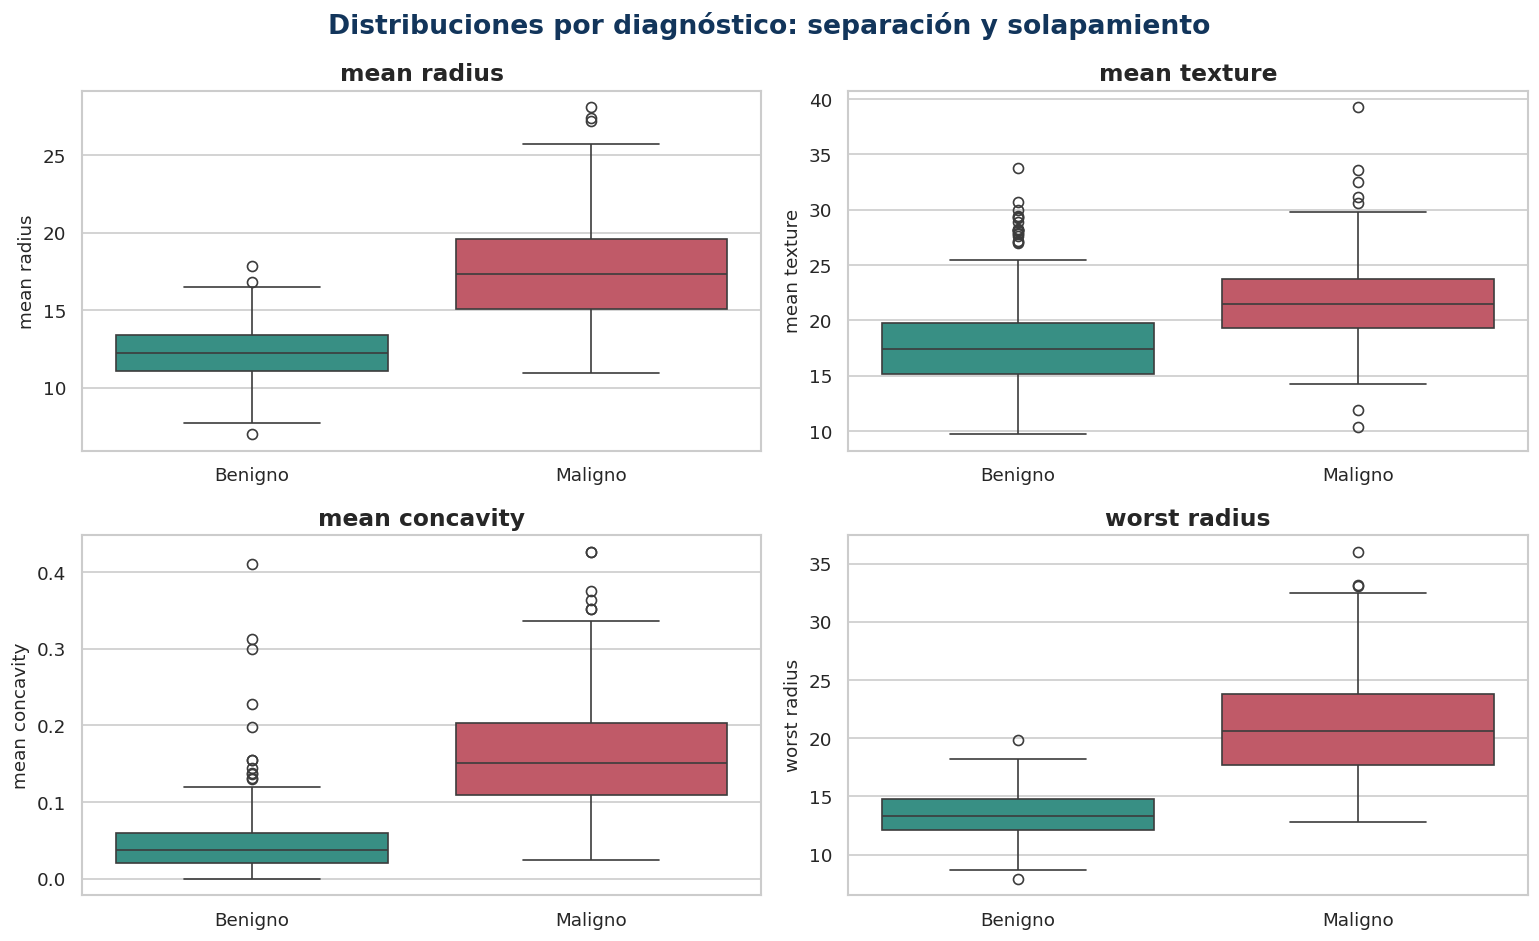

In [7]:
variables_visual = ["mean radius", "mean texture", "mean concavity", "worst radius"]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, variable in zip(axes.flat, variables_visual):
    sns.boxplot(data=df_cancer, x="diagnostico", y=variable,
                order=["Benigno", "Maligno"], palette=[VERDE, ROJO], ax=ax)
    ax.set_title(variable)
    ax.set_xlabel("")
fig.suptitle("Distribuciones por diagnóstico: separación y solapamiento", fontsize=16,
             fontweight="bold", color=AZUL)
plt.tight_layout()
plt.show()

### Lectura analítica

Algunas mediciones presentan diferencias visibles entre clases, pero también hay solapamiento. Por tanto:

- una sola regla manual no será perfecta;
- conviene combinar varias variables;
- la predicción debe evaluarse fuera de la muestra;
- los errores no tienen el mismo costo: en este contexto educativo, un **falso negativo** (maligno clasificado como benigno) merece especial atención.

## 3.2 Separación entrenamiento–prueba

Usaremos 75% para entrenamiento y 25% para prueba. `stratify=y` conserva aproximadamente la proporción de las clases, y `random_state=42` hace reproducible la partición.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Entrenamiento:", X_train.shape, "| proporción malignos:", round(y_train.mean(), 3))
print("Prueba:       ", X_test.shape,  "| proporción malignos:", round(y_test.mean(), 3))

Entrenamiento: (426, 30) | proporción malignos: 0.373
,Prueba:        (143, 30) | proporción malignos: 0.371


## 3.3 ¿Por qué estandarizar?

La estandarización transforma cada variable con parámetros aprendidos en entrenamiento:

\[
z_{ij}=\frac{x_{ij}-\overline{x}_{j,\text{train}}}{s_{j,\text{train}}}.
\]

Esto no vuelve normal a la variable. Solo cambia su centro y escala. Es especialmente importante para métodos basados en gradiente o regularización, como regresión logística, Perceptrón y Adaline.

El escalador debe hacer `fit` únicamente con `X_train`; sobre prueba solo se usa `transform`.

# 4. StatsModels: modelar para explicar e inferir

`StatsModels` sigue una tradición estadística. Sus resultados suelen incluir:

- estimaciones de coeficientes;
- errores estándar;
- estadísticos de prueba y valores (p);
- intervalos de confianza;
- medidas de ajuste y diagnósticos.

Para una respuesta binaria usaremos el modelo logit:

\[
\log\left(\frac{p(\mathbf{x})}{1-p(\mathbf{x})}\right)
=\beta_0+\beta_1x_1+\cdots+\beta_px_p,
\]

donde (p(\mathbf{x})=P(Y=1\mid X=\mathbf{x})). StatsModels **no añade el intercepto automáticamente** en `sm.Logit`; por eso usaremos `sm.add_constant`.

## 4.1 Selección pedagógica de predictores

Para que la tabla inferencial sea legible, ajustaremos un modelo con cuatro características. Esta selección es didáctica y se define **antes** de mirar los resultados de prueba:

- `mean radius`
- `mean texture`
- `mean smoothness`
- `mean concavity`

Las variables se estandarizan para que cada coeficiente represente el cambio asociado con una desviación estándar. En un estudio confirmatorio real, la selección debe sustentarse en teoría, diseño y un plan de análisis previo.

In [9]:
features_sm = ["mean radius", "mean texture", "mean smoothness", "mean concavity"]

scaler_sm = StandardScaler()
X_train_sm = pd.DataFrame(
    scaler_sm.fit_transform(X_train[features_sm]),
    columns=features_sm,
    index=X_train.index
)
X_test_sm = pd.DataFrame(
    scaler_sm.transform(X_test[features_sm]),
    columns=features_sm,
    index=X_test.index
)

print("Medias en entrenamiento después de estandarizar:")
print(X_train_sm.mean().round(4).to_string())
print("\nDesviaciones estándar poblacionales aproximadas:")
print(X_train_sm.std(ddof=0).round(4).to_string())

Medias en entrenamiento después de estandarizar:
,mean radius       -0.0
,mean texture      -0.0
,mean smoothness    0.0
,mean concavity    -0.0
,
,Desviaciones estándar poblacionales aproximadas:
,mean radius        1.0
,mean texture       1.0
,mean smoothness    1.0
,mean concavity     1.0


In [10]:
if STATSMODELS_AVAILABLE:
    X_train_sm_const = sm.add_constant(X_train_sm, has_constant="add")
    X_test_sm_const = sm.add_constant(X_test_sm, has_constant="add")

    modelo_sm = sm.Logit(y_train, X_train_sm_const)
    resultado_sm = modelo_sm.fit(disp=False, maxiter=300)
    print(resultado_sm.summary())
else:
    print("StatsModels no está instalado. Ejecute `%pip install statsmodels`, reinicie el kernel y vuelva a ejecutar.")

StatsModels no está instalado. Ejecute `%pip install statsmodels`, reinicie el kernel y vuelva a ejecutar.


## 4.2 De coeficientes a *odds ratios*

En el modelo logit, (e^{\beta_j}) es el factor multiplicativo sobre las *odds* asociado con aumentar (x_j) una unidad, manteniendo constantes las demás variables.

Como estandarizamos, una unidad equivale a **una desviación estándar del predictor en entrenamiento**.

Interpretación responsable:

- intervalo de confianza que no contiene 1: evidencia de asociación condicional al modelo;
- intervalo amplio: estimación imprecisa;
- valor (p): no mide tamaño del efecto ni importancia predictiva;
- asociación: no implica causalidad.

In [11]:
if STATSMODELS_AVAILABLE:
    ci = resultado_sm.conf_int()
    tabla_or = pd.DataFrame({
        "coeficiente": resultado_sm.params,
        "error_estandar": resultado_sm.bse,
        "valor_p": resultado_sm.pvalues,
        "OR": np.exp(resultado_sm.params),
        "OR_IC95_inf": np.exp(ci[0]),
        "OR_IC95_sup": np.exp(ci[1]),
    })
    print(tabla_or.round(4).to_string())
else:
    print("Resultado pendiente: instale StatsModels y ejecute nuevamente la sección 4.")

Resultado pendiente: instale StatsModels y ejecute nuevamente la sección 4.


In [12]:
if STATSMODELS_AVAILABLE:
    prob_sm = resultado_sm.predict(X_test_sm_const)
    pred_sm = (prob_sm >= 0.50).astype(int)

    metricas_sm = pd.Series({
        "accuracy": accuracy_score(y_test, pred_sm),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred_sm),
        "precision_maligno": precision_score(y_test, pred_sm),
        "recall_maligno": recall_score(y_test, pred_sm),
        "f1_maligno": f1_score(y_test, pred_sm),
        "roc_auc": roc_auc_score(y_test, prob_sm),
    })
    print("Métricas de prueba — StatsModels (umbral 0.50)")
    print(metricas_sm.round(3).to_string())
else:
    print("Resultado pendiente: instale StatsModels y ejecute nuevamente la sección 4.")

Resultado pendiente: instale StatsModels y ejecute nuevamente la sección 4.


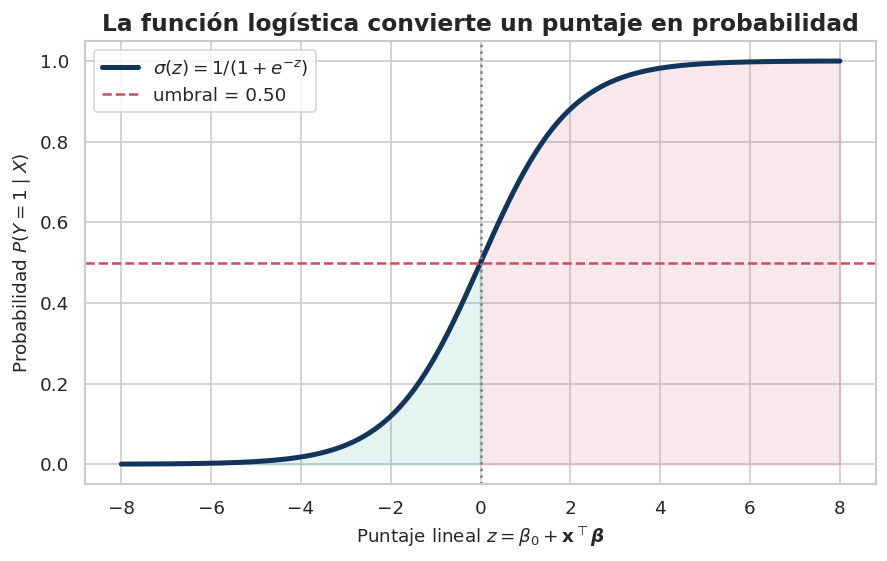

In [13]:
z = np.linspace(-8, 8, 400)
sigmoide = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(z, sigmoide, color=AZUL, linewidth=3, label=r"$\sigma(z)=1/(1+e^{-z})$")
ax.axhline(0.5, color=ROJO, linestyle="--", label="umbral = 0.50")
ax.axvline(0, color="gray", linestyle=":")
ax.fill_between(z, 0, sigmoide, where=(sigmoide >= 0.5), color=ROJO, alpha=0.12)
ax.fill_between(z, 0, sigmoide, where=(sigmoide < 0.5), color=VERDE, alpha=0.12)
ax.set_xlabel(r"Puntaje lineal $z=\beta_0+\mathbf{x}^{\top}\boldsymbol{\beta}$")
ax.set_ylabel(r"Probabilidad $P(Y=1\mid X)$")
ax.set_title("La función logística convierte un puntaje en probabilidad")
ax.legend()
plt.show()

# 5. Scikit-Learn: modelar para predecir y generalizar

Scikit-Learn ofrece una interfaz uniforme:

```python
estimador.fit(X_train, y_train)
estimador.predict(X_test)
estimador.predict_proba(X_test)
estimador.score(X_test, y_test)
```

Sus fortalezas incluyen preprocesamiento, *pipelines*, validación cruzada, selección de hiperparámetros y muchas métricas. La regresión logística de Scikit-Learn usa regularización por defecto, una práctica habitual en aprendizaje automático.

## 5.1 El *pipeline* como unidad reproducible

Un `Pipeline` encadena operaciones. Durante `fit`:

1. el escalador aprende media y desviación con entrenamiento;
2. transforma entrenamiento;
3. el clasificador aprende con los datos transformados.

Durante `predict`, el mismo escalador transforma los datos nuevos sin recalcular sus parámetros. Esto reduce fugas y evita inconsistencias.

In [14]:
modelo_lr = Pipeline(steps=[
    ("escalador", StandardScaler()),
    ("clasificador", LogisticRegression(max_iter=5000, random_state=42))
])

modelo_lr.fit(X_train, y_train)
prob_lr = modelo_lr.predict_proba(X_test)[:, 1]
pred_lr = modelo_lr.predict(X_test)

print(modelo_lr)

Pipeline(steps=[('escalador', StandardScaler()),
,                ('clasificador',
,                 LogisticRegression(max_iter=5000, random_state=42))])


## 5.2 Métricas de clasificación

Con la clase positiva `maligno = 1`:

- **Exactitud:** proporción total de aciertos.
- **Precisión:** entre los predichos malignos, cuántos realmente lo son.
- **Sensibilidad o *recall*:** entre los malignos reales, cuántos detecta el modelo.
- **Especificidad:** entre los benignos reales, cuántos reconoce como benignos.
- **(F_1):** media armónica entre precisión y sensibilidad.
- **ROC-AUC:** capacidad de ordenar positivos por encima de negativos a través de todos los umbrales.

\[
\text{precisión}=\frac{VP}{VP+FP},\qquad
\text{sensibilidad}=\frac{VP}{VP+FN},\qquad
F_1=2\frac{\text{precisión}\cdot\text{sensibilidad}}
{\text{precisión}+\text{sensibilidad}}.
\]

In [15]:
metricas_lr = pd.Series({
    "accuracy": accuracy_score(y_test, pred_lr),
    "balanced_accuracy": balanced_accuracy_score(y_test, pred_lr),
    "precision_maligno": precision_score(y_test, pred_lr),
    "recall_maligno": recall_score(y_test, pred_lr),
    "f1_maligno": f1_score(y_test, pred_lr),
    "roc_auc": roc_auc_score(y_test, prob_lr),
})

print("Métricas de prueba — Scikit-Learn")
print(metricas_lr.round(3).to_string())
print("\nReporte por clase")
print(classification_report(y_test, pred_lr, target_names=["Benigno", "Maligno"], digits=3))

Métricas de prueba — Scikit-Learn
,accuracy             0.965
,balanced_accuracy    0.957
,precision_maligno    0.980
,recall_maligno       0.925
,f1_maligno           0.951
,roc_auc              0.996
,
,Reporte por clase
,              precision    recall  f1-score   support
,
,     Benigno      0.957     0.989     0.973        90
,     Maligno      0.980     0.925     0.951        53
,
,    accuracy                          0.965       143
,   macro avg      0.968     0.957     0.962       143
,weighted avg      0.966     0.965     0.965       143
,


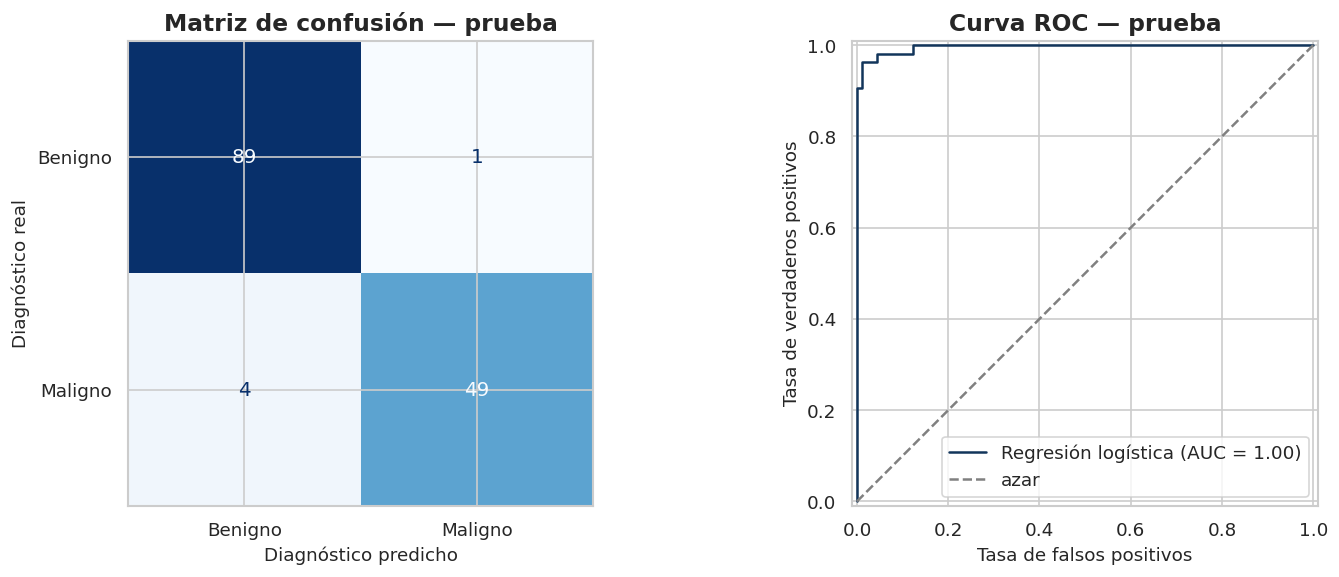

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_lr,
    display_labels=["Benigno", "Maligno"],
    cmap="Blues", colorbar=False, ax=axes[0]
)
axes[0].set_title("Matriz de confusión — prueba")
axes[0].set_xlabel("Diagnóstico predicho")
axes[0].set_ylabel("Diagnóstico real")

RocCurveDisplay.from_predictions(y_test, prob_lr, name="Regresión logística", ax=axes[1], color=AZUL)
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="azar")
axes[1].set_title("Curva ROC — prueba")
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Tasa de verdaderos positivos")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### Cómo leer la matriz de confusión

Las filas representan la clase **real** y las columnas la clase **predicha**.

| | Predicho benigno | Predicho maligno |
|---|---:|---:|
| **Real benigno** | verdadero negativo | falso positivo |
| **Real maligno** | falso negativo | verdadero positivo |

No basta decir “el modelo acierta mucho”. Debemos localizar **qué errores comete** y evaluar su costo en el problema real.

## 5.3 El umbral también es una decisión

La regresión logística estima probabilidades. La clase se obtiene al comparar con un umbral (c):

\[
\widehat y=\mathbb{1}\{\widehat p\ge c\}.
\]

Reducir (c) suele aumentar la sensibilidad, pero también puede producir más falsos positivos. El umbral no debe elegirse solo por conveniencia matemática; debe reflejar costos, recursos y contexto.

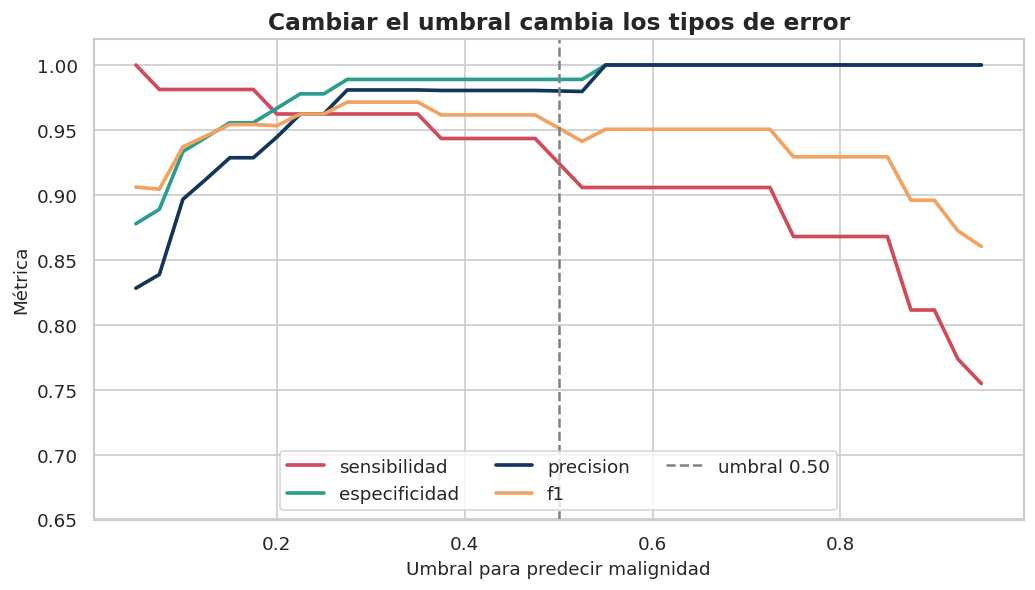

In [17]:
umbrales = np.linspace(0.05, 0.95, 37)
filas = []
for u in umbrales:
    pred_u = (prob_lr >= u).astype(int)
    filas.append({
        "umbral": u,
        "precision": precision_score(y_test, pred_u, zero_division=0),
        "sensibilidad": recall_score(y_test, pred_u),
        "especificidad": recall_score(y_test, pred_u, pos_label=0),
        "f1": f1_score(y_test, pred_u, zero_division=0),
    })
metricas_umbral = pd.DataFrame(filas)

fig, ax = plt.subplots(figsize=(10, 5.2))
for col, color in zip(["sensibilidad", "especificidad", "precision", "f1"],
                      [ROJO, VERDE, AZUL, NARANJA]):
    ax.plot(metricas_umbral["umbral"], metricas_umbral[col], label=col, linewidth=2.2, color=color)
ax.axvline(0.5, linestyle="--", color="gray", label="umbral 0.50")
ax.set_ylim(0.65, 1.02)
ax.set_xlabel("Umbral para predecir malignidad")
ax.set_ylabel("Métrica")
ax.set_title("Cambiar el umbral cambia los tipos de error")
ax.legend(ncol=3, loc="lower center")
plt.show()

## 5.4 Validación cruzada

Una única partición puede favorecer o perjudicar accidentalmente al modelo. En validación cruzada estratificada de (K) pliegues:

1. se divide el conjunto de entrenamiento en (K) partes;
2. se entrena con (K-1) y se valida con la restante;
3. se repite hasta usar cada parte como validación;
4. se resume la distribución de las métricas.

El conjunto de prueba continúa reservado para la evaluación final.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "recall_maligno": "recall",
    "roc_auc": "roc_auc",
}

cv_lr = cross_validate(modelo_lr, X_train, y_train, cv=cv, scoring=scoring)
resumen_cv = pd.DataFrame({
    metrica: [cv_lr[f"test_{metrica}"].mean(), cv_lr[f"test_{metrica}"].std(ddof=1)]
    for metrica in scoring
}, index=["media", "desviacion"])

print("Validación cruzada en entrenamiento")
print(resumen_cv.round(3).to_string())

Validación cruzada en entrenamiento
,            accuracy  recall_maligno  roc_auc
,media          0.972           0.944    0.991
,desviacion     0.018           0.041    0.010


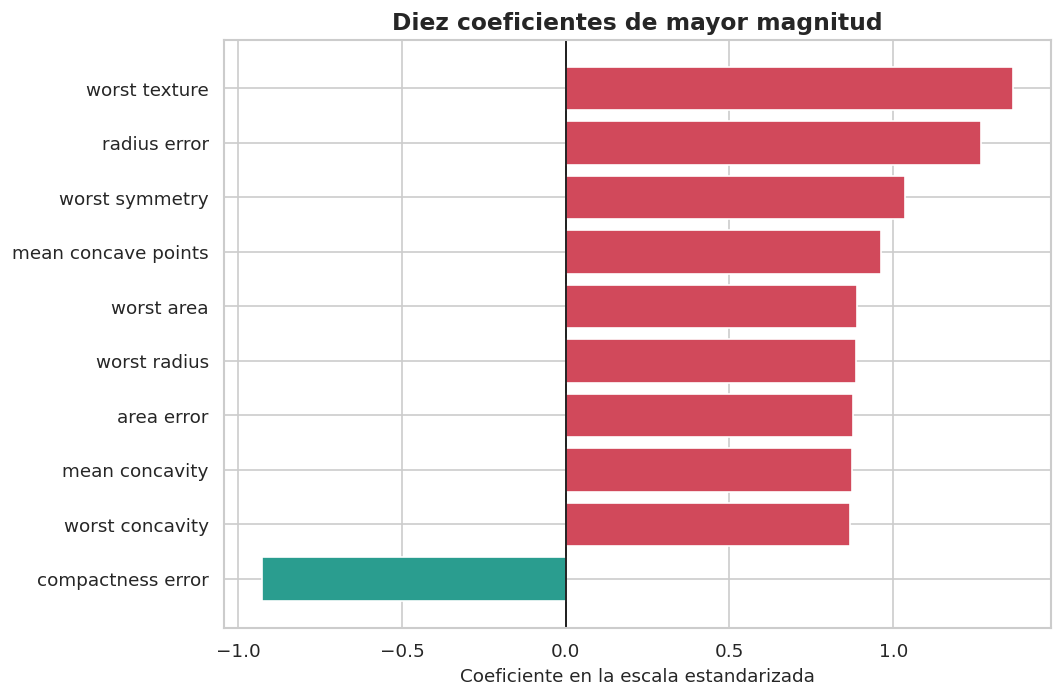

In [19]:
coef_lr = modelo_lr.named_steps["clasificador"].coef_[0]
tabla_coef_lr = pd.DataFrame({"variable": X.columns, "coeficiente_estandarizado": coef_lr})
tabla_coef_lr["magnitud"] = tabla_coef_lr["coeficiente_estandarizado"].abs()
top_coef = tabla_coef_lr.nlargest(10, "magnitud").sort_values("coeficiente_estandarizado")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_coef["variable"], top_coef["coeficiente_estandarizado"],
        color=np.where(top_coef["coeficiente_estandarizado"] >= 0, ROJO, VERDE))
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Coeficiente en la escala estandarizada")
ax.set_title("Diez coeficientes de mayor magnitud")
plt.tight_layout()
plt.show()

> **Cuidado:** un coeficiente grande no demuestra causalidad ni garantiza “importancia” universal. La magnitud depende de la escala, la regularización y la correlación entre predictores. Es una descripción del modelo ajustado.

## 5.5 StatsModels frente a Scikit-Learn

| Pregunta | StatsModels | Scikit-Learn |
|---|---|---|
| Enfoque central | inferencia y modelación estadística | predicción y generalización |
| Interfaz frecuente | fórmulas/matrices y tablas de resultados | `fit`, `predict`, `transform` |
| Resultados típicos | coeficientes, errores estándar, IC, valores (p) | métricas, CV, *pipelines*, búsqueda de hiperparámetros |
| Intercepto en `Logit` | se añade explícitamente | se incluye por defecto |
| Regularización logística | no en el ajuste clásico | sí por defecto |
| Mejor elección cuando... | interesa explicar asociaciones y cuantificar incertidumbre | interesa construir un flujo predictivo reproducible |

No son rivales. Responden a prioridades distintas y pueden complementarse.

In [20]:
# Comparación justa: mismas cuatro variables y regularización numéricamente despreciable.
modelo_sk_mismas = LogisticRegression(C=1e12, solver="lbfgs", max_iter=5000)
modelo_sk_mismas.fit(X_train_sm, y_train)

comparacion_coef = pd.DataFrame({
    "parametro": ["const"] + features_sm,
    "Scikit-Learn": np.r_[modelo_sk_mismas.intercept_[0], modelo_sk_mismas.coef_[0]],
})

if STATSMODELS_AVAILABLE:
    comparacion_coef["StatsModels"] = resultado_sm.params.reindex(comparacion_coef["parametro"]).to_numpy()
    comparacion_coef["diferencia_abs"] = (
        comparacion_coef["Scikit-Learn"] - comparacion_coef["StatsModels"]
    ).abs()
    print(comparacion_coef.round(5).to_string(index=False))
else:
    print("Coeficientes Scikit-Learn con las mismas variables:")
    print(comparacion_coef.round(5).to_string(index=False))
    print("\nInstale StatsModels para completar la comparación numérica.")

Coeficientes Scikit-Learn con las mismas variables:
,      parametro  Scikit-Learn
,          const      -0.81845
,    mean radius       4.67848
,   mean texture       1.80493
,mean smoothness       1.86030
, mean concavity       1.46045
,
,Instale StatsModels para completar la comparación numérica.


# 6. Del modelo lineal a una neurona artificial

Perceptrón y Adaline comparten una unidad lineal:

\[
z=b+\sum_{j=1}^{p}w_jx_j=b+\mathbf{w}^{\top}\mathbf{x}.
\]

- (x_j): entrada o característica.
- (w_j): peso aprendido.
- (b): sesgo o intercepto.
- (z): combinación lineal.
- función de activación/decisión: transforma (z) en una salida.

Esta unidad es un antecedente histórico de las redes neuronales modernas.

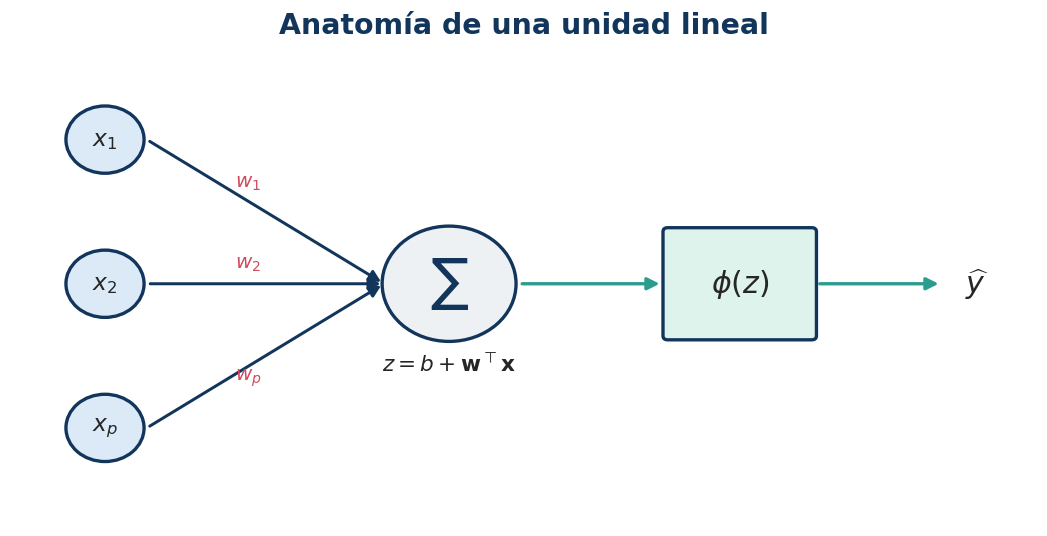

In [21]:
fig, ax = plt.subplots(figsize=(11, 5.2))
ax.set_xlim(0, 11)
ax.set_ylim(0, 6)
ax.axis("off")

entradas = [(1, 4.8, r"$x_1$"), (1, 3.0, r"$x_2$"), (1, 1.2, r"$x_p$")]
for x, y0, etiqueta in entradas:
    ax.add_patch(plt.Circle((x, y0), 0.42, facecolor=AZUL_CLARO, edgecolor=AZUL, linewidth=2))
    ax.text(x, y0, etiqueta, ha="center", va="center", fontsize=14)
    ax.add_patch(FancyArrowPatch((1.45, y0), (4.0, 3.0), arrowstyle="-|>",
                                 mutation_scale=14, color=AZUL, linewidth=1.8))

ax.text(2.4, 4.2, r"$w_1$", color=ROJO, fontsize=12)
ax.text(2.4, 3.2, r"$w_2$", color=ROJO, fontsize=12)
ax.text(2.4, 1.8, r"$w_p$", color=ROJO, fontsize=12)

ax.add_patch(plt.Circle((4.7, 3.0), 0.72, facecolor=GRIS, edgecolor=AZUL, linewidth=2))
ax.text(4.7, 3.0, r"$\sum$", ha="center", va="center", fontsize=24, color=AZUL)
ax.text(4.7, 1.9, r"$z=b+\mathbf{w}^{\top}\mathbf{x}$", ha="center", fontsize=13)

ax.add_patch(FancyArrowPatch((5.45, 3.0), (7.0, 3.0), arrowstyle="-|>",
                             mutation_scale=15, color=VERDE, linewidth=2))
act = FancyBboxPatch((7.05, 2.35), 1.55, 1.3, boxstyle="round,pad=.05",
                     facecolor="#DDF3EC", edgecolor=AZUL, linewidth=2)
ax.add_patch(act)
ax.text(7.825, 3.0, r"$\phi(z)$", ha="center", va="center", fontsize=18)
ax.add_patch(FancyArrowPatch((8.65, 3.0), (10.0, 3.0), arrowstyle="-|>",
                             mutation_scale=15, color=VERDE, linewidth=2))
ax.text(10.25, 3.0, r"$\widehat y$", fontsize=18, va="center")

ax.set_title("Anatomía de una unidad lineal", fontsize=17, fontweight="bold", color=AZUL)
plt.show()

# 7. Perceptrón

El Perceptrón binario produce una decisión escalón:

\[
\widehat y=
\begin{cases}
+1,&z\ge 0,\\
-1,&z<0.
\end{cases}
\]

Para cada observación mal clasificada actualiza:

\[
\mathbf{w}\leftarrow\mathbf{w}+\eta y_i\mathbf{x}_i,
\qquad
b\leftarrow b+\eta y_i,
\]

donde (eta>0) es la tasa de aprendizaje. Si la observación queda bien clasificada, no actualiza.

**Teorema de convergencia:** si las clases son linealmente separables y (eta>0), el algoritmo encuentra una frontera separadora en un número finito de actualizaciones. Si no son separables, puede seguir cometiendo errores y no estabilizarse.

## 7.1 Datos visuales: dos especies de Iris

Para ver la frontera utilizaremos dos especies (`setosa` y `versicolor`) y dos variables: longitud y ancho del pétalo. Aquí una fila es una flor y el objetivo es su especie.

In [22]:
iris = load_iris(as_frame=True)
df_iris = iris.frame.loc[iris.frame["target"] < 2].copy()
features_iris = ["petal length (cm)", "petal width (cm)"]

X_iris = df_iris[features_iris]
y_iris01 = df_iris["target"].astype(int)       # 0=setosa, 1=versicolor
y_iris_pm = y_iris01.map({0: -1, 1: 1})       # codificación del Perceptrón didáctico

X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris, y_iris_pm, test_size=0.25, stratify=y_iris_pm, random_state=42
)

scaler_iris = StandardScaler()
X_iris_train_z = scaler_iris.fit_transform(X_iris_train)
X_iris_test_z = scaler_iris.transform(X_iris_test)

print("Entrenamiento:", X_iris_train.shape, "| Prueba:", X_iris_test.shape)

Entrenamiento: (75, 2) | Prueba: (25, 2)


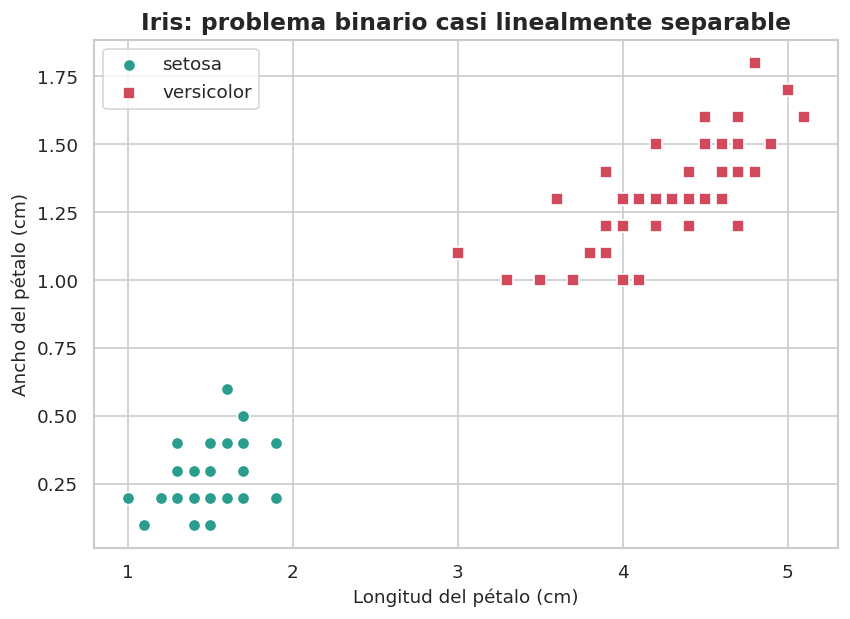

In [23]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for clase, nombre, color, marcador in [(-1, "setosa", VERDE, "o"), (1, "versicolor", ROJO, "s")]:
    mask = y_iris_pm == clase
    ax.scatter(X_iris.loc[mask, features_iris[0]], X_iris.loc[mask, features_iris[1]],
               label=nombre, color=color, marker=marcador, s=55, edgecolor="white")
ax.set_xlabel("Longitud del pétalo (cm)")
ax.set_ylabel("Ancho del pétalo (cm)")
ax.set_title("Iris: problema binario casi linealmente separable")
ax.legend()
plt.show()

## 7.2 Implementación desde cero

La clase siguiente separa claramente cuatro operaciones:

1. calcular (z=b+\mathbf{w}^{\top}\mathbf{x});
2. convertir (z) en clase;
3. actualizar si hay error;
4. registrar errores por época.

Una **época** es una pasada completa por todas las observaciones de entrenamiento.

In [24]:
class PerceptronDidactico:
    def __init__(self, eta=0.1, epochs=20, random_state=42):
        self.eta = eta
        self.epochs = epochs
        self.random_state = random_state

    def net_input(self, X):
        return np.asarray(X) @ self.w_[1:] + self.w_[0]

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, -1)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        self.w_ = np.zeros(X.shape[1] + 1, dtype=float)
        self.errors_ = []

        for _ in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                if target * self.net_input(xi) <= 0:
                    self.w_[1:] += self.eta * target * xi
                    self.w_[0] += self.eta * target
                    errors += 1
            self.errors_.append(errors)
        return self

Pesos aprendidos: [0.1   0.092 0.129]
,Exactitud en prueba: 1.0


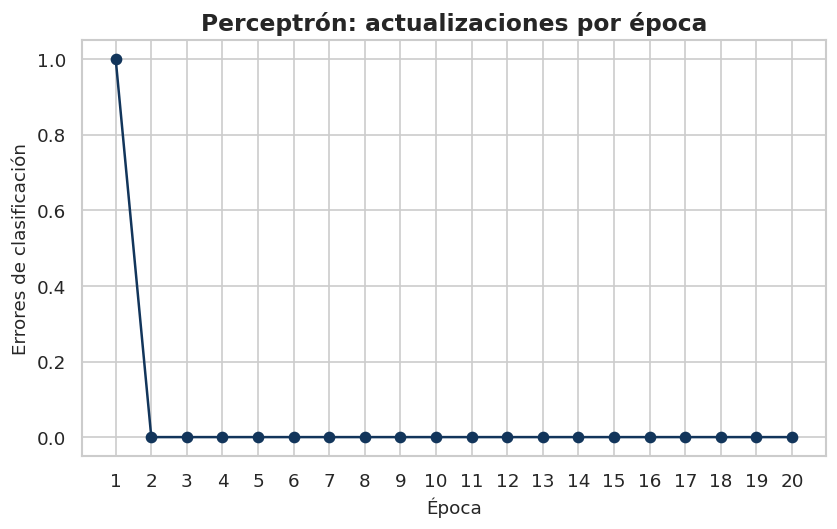

In [25]:
perceptron_manual = PerceptronDidactico(eta=0.1, epochs=20)
perceptron_manual.fit(X_iris_train_z, y_iris_train)

pred_per_manual = perceptron_manual.predict(X_iris_test_z)
print("Pesos aprendidos:", np.round(perceptron_manual.w_, 3))
print("Exactitud en prueba:", round(accuracy_score(y_iris_test, pred_per_manual), 3))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, len(perceptron_manual.errors_) + 1), perceptron_manual.errors_,
        marker="o", color=AZUL)
ax.set_xlabel("Época")
ax.set_ylabel("Errores de clasificación")
ax.set_title("Perceptrón: actualizaciones por época")
ax.set_xticks(range(1, len(perceptron_manual.errors_) + 1))
plt.show()

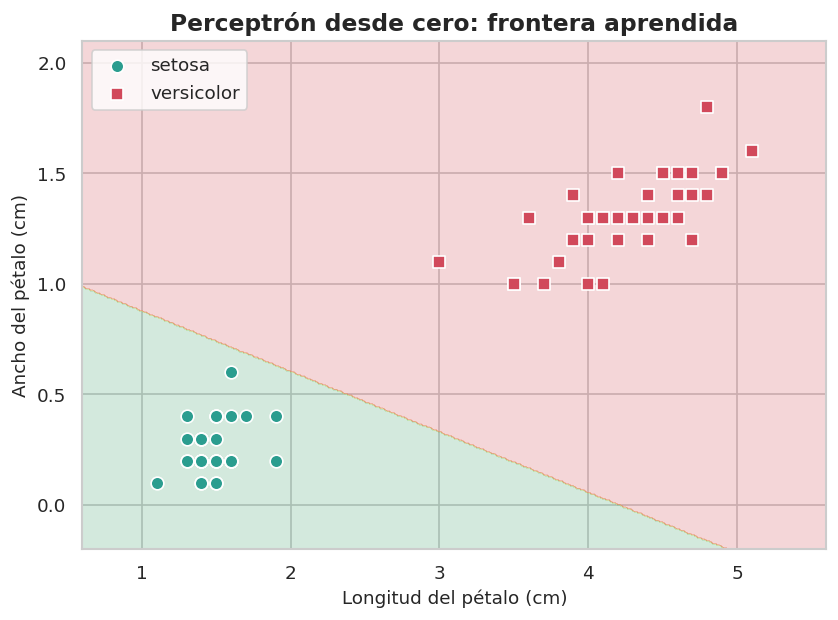

In [26]:
def plot_frontera(modelo, X_original, y, transformador=None, titulo="Frontera de decisión"):
    columnas = list(X_original.columns) if hasattr(X_original, "columns") else None
    X_np = np.asarray(X_original)
    y_np = np.asarray(y)
    x1_min, x1_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
    x2_min, x2_max = X_np[:, 1].min() - 0.3, X_np[:, 1].max() + 0.3
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, 350),
        np.linspace(x2_min, x2_max, 350)
    )
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    if transformador is not None:
        grid_entrada = pd.DataFrame(grid, columns=columnas) if columnas is not None else grid
        grid_modelo = transformador.transform(grid_entrada)
    else:
        grid_modelo = grid
    zz = np.asarray(modelo.predict(grid_modelo)).reshape(xx1.shape)

    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.contourf(xx1, xx2, zz, alpha=0.18, cmap="RdYlGn_r")
    for clase, nombre, color, marcador in [(-1, "setosa", VERDE, "o"), (1, "versicolor", ROJO, "s")]:
        mask = y_np == clase
        ax.scatter(X_np[mask, 0], X_np[mask, 1], label=nombre,
                   color=color, marker=marcador, edgecolor="white", s=58)
    ax.set_xlabel("Longitud del pétalo (cm)")
    ax.set_ylabel("Ancho del pétalo (cm)")
    ax.set_title(titulo)
    ax.legend()
    plt.show()

plot_frontera(
    perceptron_manual, X_iris_train, y_iris_train,
    transformador=scaler_iris,
    titulo="Perceptrón desde cero: frontera aprendida"
)

## 7.3 Perceptrón con Scikit-Learn

`sklearn.linear_model.Perceptron` implementa una versión eficiente y compatible con `Pipeline`. La estandarización queda dentro del flujo, de modo que cada pliegue de validación aprende su propio escalador.

In [27]:
perceptron_sk = make_pipeline(
    StandardScaler(),
    Perceptron(max_iter=1000, eta0=0.1, tol=1e-3, random_state=42)
)
perceptron_sk.fit(X_iris_train, y_iris_train)
pred_per_sk = perceptron_sk.predict(X_iris_test)

print("Exactitud en prueba — Perceptrón Scikit-Learn:",
      round(accuracy_score(y_iris_test, pred_per_sk), 3))
print(confusion_matrix(y_iris_test, pred_per_sk))

Exactitud en prueba — Perceptrón Scikit-Learn: 1.0
,[[13  0]
, [ 0 12]]


# 8. Adaline (*Adaptive Linear Neuron*)

Adaline también calcula (z=b+\mathbf{w}^{\top}\mathbf{x}), pero durante el entrenamiento usa la **activación identidad**:

\[
a(z)=z.
\]

Minimiza una función diferenciable, por ejemplo el error cuadrático medio:

\[
J(\mathbf{w},b)=\frac{1}{2n}\sum_{i=1}^{n}
\left(y_i-(b+\mathbf{w}^{\top}\mathbf{x}_i)\right)^2.
\]

Con descenso de gradiente por lotes:

\[
\mathbf{w}\leftarrow\mathbf{w}+\eta\frac{1}{n}X^{\top}(\mathbf{y}-\mathbf{z}),
\qquad
b\leftarrow b+\eta\,\overline{(\mathbf{y}-\mathbf{z})}.
\]

Solo después del aprendizaje aplica un escalón para decidir la clase. A diferencia del Perceptrón, **todas las observaciones contribuyen a la actualización**, no únicamente las mal clasificadas.

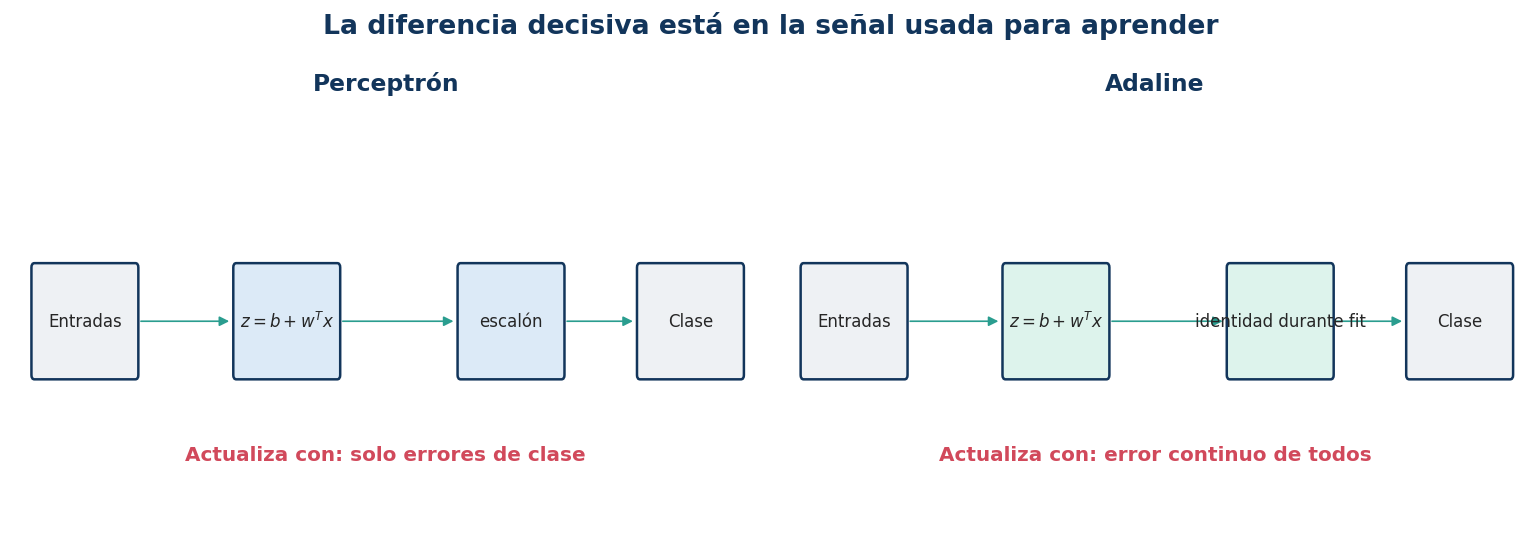

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, titulo, activacion, actualizacion, color in [
    (axes[0], "Perceptrón", "escalón", "solo errores de clase", AZUL_CLARO),
    (axes[1], "Adaline", "identidad durante fit", "error continuo de todos", "#DDF3EC"),
]:
    ax.set_xlim(0, 10); ax.set_ylim(0, 4); ax.axis("off")
    elementos = [(0.3, "Entradas"), (3.0, r"$z=b+w^Tx$"), (6.0, activacion), (8.4, "Clase")]
    for j, (x, label) in enumerate(elementos):
        p = FancyBboxPatch((x, 1.45), 1.35, 1.0, boxstyle="round,pad=.04",
                           facecolor=color if j in [1, 2] else GRIS,
                           edgecolor=AZUL, linewidth=1.5)
        ax.add_patch(p)
        ax.text(x + .675, 1.95, label, ha="center", va="center", fontsize=10)
        if j < 3:
            ax.add_patch(FancyArrowPatch((x+1.38,1.95),(elementos[j+1][0]-0.05,1.95),
                                         arrowstyle="-|>", mutation_scale=12, color=VERDE))
    ax.text(5, 0.65, f"Actualiza con: {actualizacion}", ha="center", color=ROJO, fontweight="bold")
    ax.set_title(titulo, color=AZUL, fontweight="bold")
fig.suptitle("La diferencia decisiva está en la señal usada para aprender",
             fontsize=16, fontweight="bold", color=AZUL)
plt.tight_layout()
plt.show()

## 8.1 Implementación desde cero

La estandarización es crucial porque el gradiente depende de la escala de las variables. Con escalas muy distintas, una misma tasa (eta) puede ser demasiado grande para unas direcciones y demasiado pequeña para otras.

In [29]:
class AdalineGD:
    def __init__(self, eta=0.05, epochs=40):
        self.eta = eta
        self.epochs = epochs

    def net_input(self, X):
        return np.asarray(X) @ self.w_[1:] + self.w_[0]

    def activation(self, X):
        return self.net_input(X)

    def predict(self, X):
        return np.where(self.activation(X) >= 0.0, 1, -1)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        self.w_ = np.zeros(X.shape[1] + 1, dtype=float)
        self.losses_ = []

        for _ in range(self.epochs):
            output = self.activation(X)
            errors = y - output
            self.w_[1:] += self.eta * (X.T @ errors) / X.shape[0]
            self.w_[0] += self.eta * errors.mean()
            loss = 0.5 * np.mean(errors ** 2)
            self.losses_.append(loss)
        return self

Pesos aprendidos: [0.013 0.513 0.465]
,Exactitud en prueba: 1.0


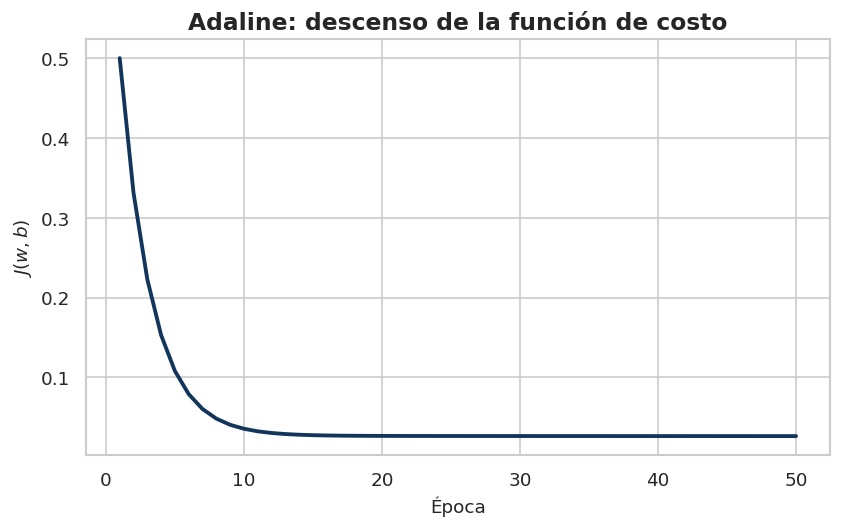

In [30]:
adaline = AdalineGD(eta=0.1, epochs=50)
adaline.fit(X_iris_train_z, y_iris_train)
pred_adaline = adaline.predict(X_iris_test_z)

print("Pesos aprendidos:", np.round(adaline.w_, 3))
print("Exactitud en prueba:", round(accuracy_score(y_iris_test, pred_adaline), 3))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, len(adaline.losses_) + 1), adaline.losses_, color=AZUL, linewidth=2.3)
ax.set_xlabel("Época")
ax.set_ylabel(r"$J(w,b)$")
ax.set_title("Adaline: descenso de la función de costo")
plt.show()

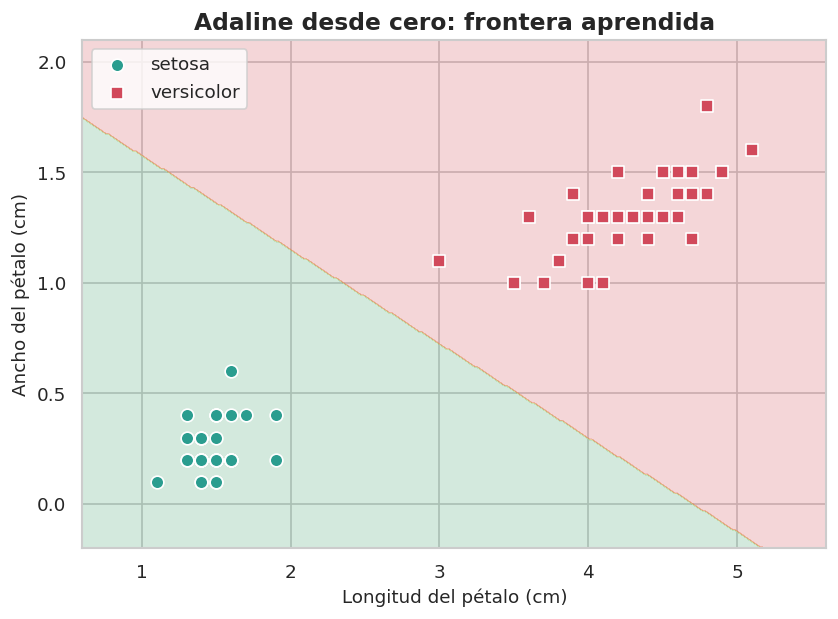

In [31]:
plot_frontera(
    adaline, X_iris_train, y_iris_train,
    transformador=scaler_iris,
    titulo="Adaline desde cero: frontera aprendida"
)

## 8.2 ¿Existe `Adaline` en Scikit-Learn?

No hay una clase pública llamada `Adaline`. Una aproximación es `SGDClassifier(loss="squared_error")`, que usa pérdida cuadrática y descenso de gradiente **estocástico**. No es idéntico a nuestra implementación por lotes, pero comparte la idea de aprender mediante error continuo.

In [32]:
adaline_sgd = make_pipeline(
    StandardScaler(),
    SGDClassifier(
        loss="squared_error",
        penalty=None,
        learning_rate="constant",
        eta0=0.01,
        max_iter=2000,
        tol=1e-4,
        random_state=42
    )
)
adaline_sgd.fit(X_iris_train, y_iris_train)
pred_adaline_sgd = adaline_sgd.predict(X_iris_test)

print("Exactitud en prueba — aproximación con SGDClassifier:",
      round(accuracy_score(y_iris_test, pred_adaline_sgd), 3))

Exactitud en prueba — aproximación con SGDClassifier: 1.0


# 9. Comparación conceptual

| Propiedad | Perceptrón | Adaline | Regresión logística |
|---|---|---|---|
| Salida usada al aprender | clase escalón | puntaje lineal | probabilidad sigmoide |
| Señal de error | error de clasificación | error continuo | pérdida logarítmica |
| Actualiza con | casos mal clasificados | todas las observaciones | todas las observaciones |
| Función de costo suave | no en la forma clásica | sí, cuadrática | sí, log-loss |
| Entrega probabilidad | no | no | sí |
| Sensible a escala | sí | muy sensible | sí, especialmente con regularización |
| Frontera | lineal | lineal | lineal en el espacio de características |

Los tres pueden producir una frontera lineal, pero **aprenden de manera diferente**.

In [33]:
modelos_iris = {
    "Perceptrón manual": (y_iris_test, pred_per_manual),
    "Perceptrón sklearn": (y_iris_test, pred_per_sk),
    "Adaline manual": (y_iris_test, pred_adaline),
    "Adaline-SGD": (y_iris_test, pred_adaline_sgd),
}

tabla_iris = []
for nombre, (real, pred) in modelos_iris.items():
    tabla_iris.append({
        "modelo": nombre,
        "accuracy": accuracy_score(real, pred),
        "f1_versicolor": f1_score(real, pred, pos_label=1),
    })

tabla_iris = pd.DataFrame(tabla_iris).sort_values("accuracy", ascending=False)
print(tabla_iris.round(3).to_string(index=False))

            modelo  accuracy  f1_versicolor
, Perceptrón manual       1.0            1.0
,Perceptrón sklearn       1.0            1.0
,    Adaline manual       1.0            1.0
,       Adaline-SGD       1.0            1.0


## 9.1 Lo que estos resultados no demuestran

- Un buen resultado en Iris no implica que el método funcione igual en otros problemas.
- Dos variables y dos especies conforman un caso simple y casi separable.
- Exactitudes iguales no significan modelos idénticos: pueden tener fronteras, estabilidad y sensibilidad diferentes.
- El conjunto de prueba es pequeño; una diferencia de una observación cambia la métrica varios puntos porcentuales.
- La elección de modelo debe considerar el objetivo, el costo de errores, la interpretabilidad, los datos disponibles y el entorno de uso.

# 10. Lista de verificación para un análisis supervisado

Antes de comunicar resultados, responda:

1. **Pregunta:** ¿qué decisión apoyará la predicción?
2. **Unidad:** ¿qué representa una fila?
3. **Objetivo:** ¿cómo y cuándo se midió (y)?
4. **Separación:** ¿prueba permaneció aislada?
5. **Preprocesamiento:** ¿se aprendió únicamente con entrenamiento?
6. **Línea base:** ¿el modelo supera una regla sencilla?
7. **Métrica:** ¿refleja el costo real de los errores?
8. **Incertidumbre:** ¿se revisó variación con validación cruzada o remuestreo?
9. **Errores:** ¿se inspeccionaron falsos positivos y falsos negativos?
10. **Alcance:** ¿se declararon población objetivo, limitaciones y riesgos?

# 11. Ejercicios

## Ejercicio 1 — Reconocer el problema

Una universidad quiere predecir si un estudiante abandonará el programa durante el siguiente semestre.

1. ¿Cuál es la unidad de análisis?
2. Proponga tres variables (X).
3. Defina (y) sin ambigüedad.
4. ¿Es clasificación o regresión?
5. ¿Qué error puede ser más costoso y por qué?

### Solución orientativa 1

1. Una fila corresponde a un estudiante elegible al inicio del semestre.
2. Ejemplos: promedio acumulado previo, créditos aprobados y número de matrículas anteriores.
3. (y=1) si el estudiante formaliza retiro o no continúa antes de una fecha definida; (y=0) en caso contrario.
4. Clasificación binaria.
5. Depende de la acción. Si el modelo activa acompañamiento, un falso negativo deja sin apoyo a un estudiante en riesgo; un falso positivo consume recursos y puede estigmatizar. La institución debe definir costos y salvaguardas.

## Ejercicio 2 — Detectar fuga

Evalúe el procedimiento:

```python
X_z = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_z, y)
```

¿Qué está mal? Reescriba el flujo usando un `Pipeline`.

In [34]:
# Solución orientativa 2
X_train_ej, X_test_ej, y_train_ej, y_test_ej = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
pipeline_ej = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
pipeline_ej.fit(X_train_ej, y_train_ej)
print("El escalador se ajusta dentro del Pipeline usando únicamente entrenamiento.")

El escalador se ajusta dentro del Pipeline usando únicamente entrenamiento.


## Ejercicio 3 — Interpretar un *odds ratio*

Suponga que, para una variable estandarizada, se obtiene:

\[
\widehat{OR}=1.80,\qquad IC_{95\%}=(1.20,2.70).
\]

Redacte una interpretación correcta. ¿Puede afirmar causalidad?

### Solución orientativa 3

Manteniendo constantes las demás variables del modelo, aumentar el predictor en una desviación estándar se asocia con multiplicar las *odds* estimadas del evento por 1.80. El intervalo no contiene 1, lo cual aporta evidencia de asociación bajo los supuestos del modelo. No permite afirmar causalidad: faltan diseño causal, control suficiente de confusión y supuestos adicionales.

## Ejercicio 4 — Umbral y costo de errores

Compare los umbrales (0.50) y (0.25) para el modelo de cáncer. Calcule sensibilidad, precisión y número de falsos negativos. Explique cuál elegiría si la prioridad educativa fuera reducir falsos negativos.

In [35]:
# Solución orientativa 4
filas = []
for umbral in [0.50, 0.25]:
    pred = (prob_lr >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    filas.append({
        "umbral": umbral,
        "precision_maligno": precision_score(y_test, pred),
        "sensibilidad_maligno": recall_score(y_test, pred),
        "falsos_negativos": fn,
        "falsos_positivos": fp,
    })
comparacion_umbral = pd.DataFrame(filas)
print(comparacion_umbral.round(3).to_string(index=False))

 umbral  precision_maligno  sensibilidad_maligno  falsos_negativos  falsos_positivos
,   0.50              0.980                 0.925                 4                 1
,   0.25              0.962                 0.962                 2                 2


## Ejercicio 5 — Tasa de aprendizaje de Adaline

Entrene `AdalineGD` con (eta\in\{0.001,0.01,0.1,0.5}), manteniendo 30 épocas y los datos estandarizados. Grafique (J) y analice:

- velocidad de descenso;
- estabilidad;
- posible oscilación o divergencia.

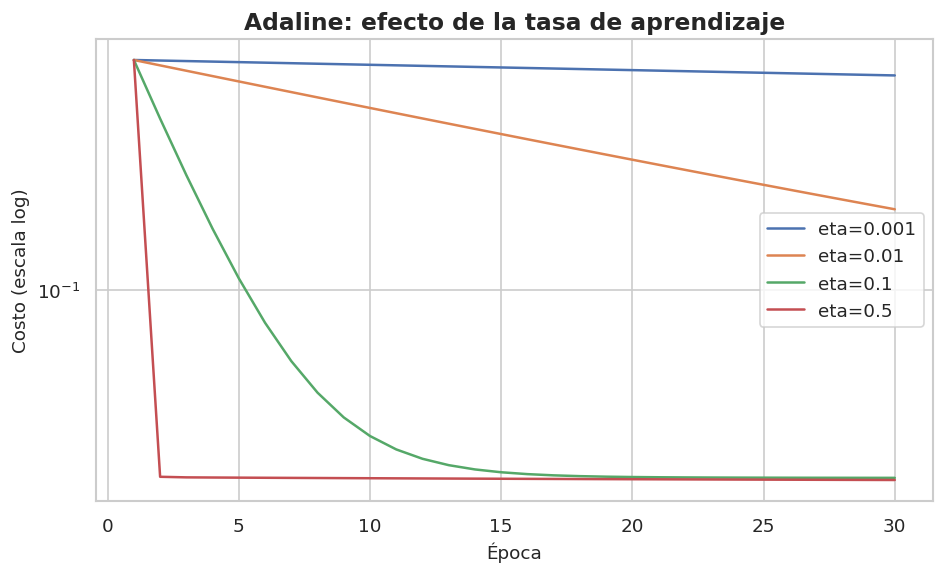

In [36]:
# Solución orientativa 5
fig, ax = plt.subplots(figsize=(9, 5))
for eta in [0.001, 0.01, 0.1, 0.5]:
    modelo = AdalineGD(eta=eta, epochs=30).fit(X_iris_train_z, y_iris_train)
    ax.plot(range(1, 31), modelo.losses_, label=f"eta={eta}")
ax.set_yscale("log")
ax.set_xlabel("Época")
ax.set_ylabel("Costo (escala log)")
ax.set_title("Adaline: efecto de la tasa de aprendizaje")
ax.legend()
plt.show()

In [37]:
# Espacio de trabajo del estudiante
wine = load_wine(as_frame=True)
X_wine = wine.data.copy()
y_wine = wine.target.copy()

print("Dimensión:", X_wine.shape)
print("Faltantes:", int(X_wine.isna().sum().sum()))
print("Clases:")
print(y_wine.value_counts().sort_index().to_string())

# Continúe aquí.

Dimensión: (178, 13)
,Faltantes: 0
,Clases:
,target
,0    59
,1    71
,2    48


In [38]:
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_wine, y_wine, test_size=0.25, stratify=y_wine, random_state=42
)

modelos_wine = {
    "Regresión logística": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=5000, random_state=42)
    ),
    "Perceptrón": make_pipeline(
        StandardScaler(), Perceptron(max_iter=2000, eta0=0.1, tol=1e-3, random_state=42)
    ),
}

cv_wine = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_wine = []
for nombre, modelo in modelos_wine.items():
    scores_acc = cross_val_score(modelo, Xw_train, yw_train, cv=cv_wine, scoring="accuracy")
    scores_f1 = cross_val_score(modelo, Xw_train, yw_train, cv=cv_wine, scoring="f1_macro")
    resultados_wine.append({
        "modelo": nombre,
        "accuracy_cv_media": scores_acc.mean(),
        "accuracy_cv_sd": scores_acc.std(ddof=1),
        "f1_macro_cv_media": scores_f1.mean(),
    })

tabla_wine = pd.DataFrame(resultados_wine).sort_values("f1_macro_cv_media", ascending=False)
print(tabla_wine.round(3).to_string(index=False))

             modelo  accuracy_cv_media  accuracy_cv_sd  f1_macro_cv_media
,         Perceptrón              0.977           0.033              0.979
,Regresión logística              0.977           0.021              0.978


# 14. Referencias y documentación

- James, G., Witten, D., Hastie, T. y Tibshirani, R. *An Introduction to Statistical Learning*.
- Raschka, S., Liu, Y. y Mirjalili, V. *Machine Learning with PyTorch and Scikit-Learn*.
- Rosenblatt, F. (1958). *The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain*.
- Widrow, B. y Hoff, M. E. (1960). *Adaptive Switching Circuits*.
- [StatsModels — modelo Logit](https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.Logit.html)
- [Scikit-Learn — modelos lineales y Perceptrón](https://scikit-learn.org/stable/modules/linear_model.html)
- [Scikit-Learn — evaluación de modelos](https://scikit-learn.org/stable/modules/model_evaluation.html)
- [Scikit-Learn — Breast Cancer Wisconsin](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)